<a href="https://colab.research.google.com/github/AbhigyanPandey08/Groundwater-Quality-Assessment-of-Ganga-and-Varuna-River-Basins-using-Ensemble-Machine-Learning/blob/main/GRB_VRB_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install rasterio
import rasterio
!pip install shp
!pip install -f http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o
from h2o.estimators.gbm import H2OGradientBoostingEstimator
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 42.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for shp: filename=shp-2.0.0-py3-none-any.whl size=27655 sha256=4927a186b9f59fce756e7ce993d259018598d535798625001b9ca574a25aeff3
  Stored in directory: /root/.cache/pip/wheels/0c/63/bb/ca1401386c417ef710500713b2a21ce84de5834c88c0f5e43c
Successfully built shp
Looking in links: http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 MB 5.4 MB/s eta 0:00:00


In [ ]:
#FILTERING and IMPUTING THE FILES
# Load Files
df_grb = pd.read_csv("Ganga_River_Basin_Renamed.csv")
df_vrb = pd.read_csv("Varuna_River_Basin_Renamed.csv")

# Rounding the Coordinates
for df in [df_grb, df_vrb]:
    df['Latitude'] = df['Latitude'].round(6)
    df['Longitude'] = df['Longitude'].round(6)

# Define Key Columns (Pollutants predicted by features)
pollutants = ['PO₄³⁻ (mg/L)', 'Fe (ppm)', 'As (ppb)', 'U (ppb)']
features = [
    'pH', 'EC (µS/cm)', 'TDS (mg/L)', 'Ca²⁺ (mg/L)', 'Mg²⁺ (mg/L)',
    'Na⁺ (mg/L)', 'K⁺ (mg/L)', 'Cl⁻ (mg/L)', 'SO₄²⁻ (mg/L)',
    'HCO₃⁻ (mg/L)', 'CO₃²⁻ (mg/L)', 'Total Hardness (mg/L as CaCO₃)',
    'NO₃⁻ (mg/L)', 'F⁻ (mg/L)'
]

# Ensure Numeric Nature
df_grb[pollutants + features] = df_grb[pollutants + features].apply(pd.to_numeric, errors='coerce')
df_vrb[pollutants + features] = df_vrb[pollutants + features].apply(pd.to_numeric, errors='coerce')

# Filter: at most 2 missing or 0 pollutant values
df_grb['missing'] = df_grb[pollutants].isna().sum(axis=1) + (df_grb[pollutants] == 0).sum(axis=1)
df_grb_filtered = df_grb[df_grb['missing'] <= 2].drop(columns='missing')

# Identify VRB Points
coords_vrb = df_vrb[['Latitude', 'Longitude']].drop_duplicates()
vrb_in_grb = df_grb_filtered.merge(coords_vrb, on=['Latitude', 'Longitude'], how='inner')
vrb_missing = df_vrb.merge(vrb_in_grb[['Latitude', 'Longitude']], on=['Latitude', 'Longitude'], how='outer', indicator=True)
vrb_only = vrb_missing[vrb_missing['_merge'] == 'left_only'].drop(columns=['_merge'])

# Filter out VRB points from GRB
grb_only = df_grb_filtered.merge(coords_vrb, on=['Latitude', 'Longitude'], how='outer', indicator=True)
grb_only = grb_only[grb_only['_merge'] == 'left_only'].drop(columns=['_merge'])

# Latitude greater than or equal to 29.5 for Uttarakhand
north_points = grb_only[grb_only['Latitude'] >= 29.5]

# Total desired count
TARGET = 1800

base = pd.concat([vrb_in_grb, vrb_only, north_points], ignore_index=True)
needed = TARGET - len(base)
grb_sampled = grb_only.drop(north_points.index).sample(n=needed, random_state=42)

df_final = pd.concat([base, grb_sampled], ignore_index=True)

# Imputation with XGBoost
def xgb_impute(df, target, features):
    df_model = df[features + [target]].dropna()
    df_model = df_model[df_model[target] > 0]
    if df_model.empty:
        return df
    model = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(df_model[features], df_model[target])
    mask = df[target].isna() | (df[target] == 0)
    to_pred = df.loc[mask, features].dropna()
    if not to_pred.empty:
        df.loc[to_pred.index, target] = model.predict(to_pred)
    return df

for col in pollutants:
    df_final = xgb_impute(df_final, col, features)
    df_vrb = xgb_impute(df_vrb, col, features)

# Save Outputs
df_final.to_csv("Ganga_River_Basin_Clean.csv", index=False)
df_vrb.to_csv("Varuna_River_Basin_Clean.csv", index=False)



XGBoost Results:
MAE: 1.226
MSE: 3.356
R² Score: 0.981

Normalized SHAP-based weights:
EC (µS/cm)                        0.380767
Fe (ppm)                          0.324762
NO₃⁻ (mg/L)                       0.056329
K⁺ (mg/L)                         0.051265
As (ppb)                          0.047814
U (ppb)                           0.025180
Total Hardness (mg/L as CaCO₃)    0.023105
F⁻ (mg/L)                         0.021804
SO₄²⁻ (mg/L)                      0.021633
Cl⁻ (mg/L)                        0.016023
HCO₃⁻ (mg/L)                      0.009032
Mg²⁺ (mg/L)                       0.008199
Ca²⁺ (mg/L)                       0.004742
pH                                0.003509
Na⁺ (mg/L)                        0.003106
PO₄³⁻ (mg/L)                      0.002671
CO₃²⁻ (mg/L)                      0.000060
TDS (mg/L)                        0.000000
dtype: float32

Normalized Permutation-based weights:
EC (µS/cm)                        5.094726e-01
Fe (ppm)                          4.2

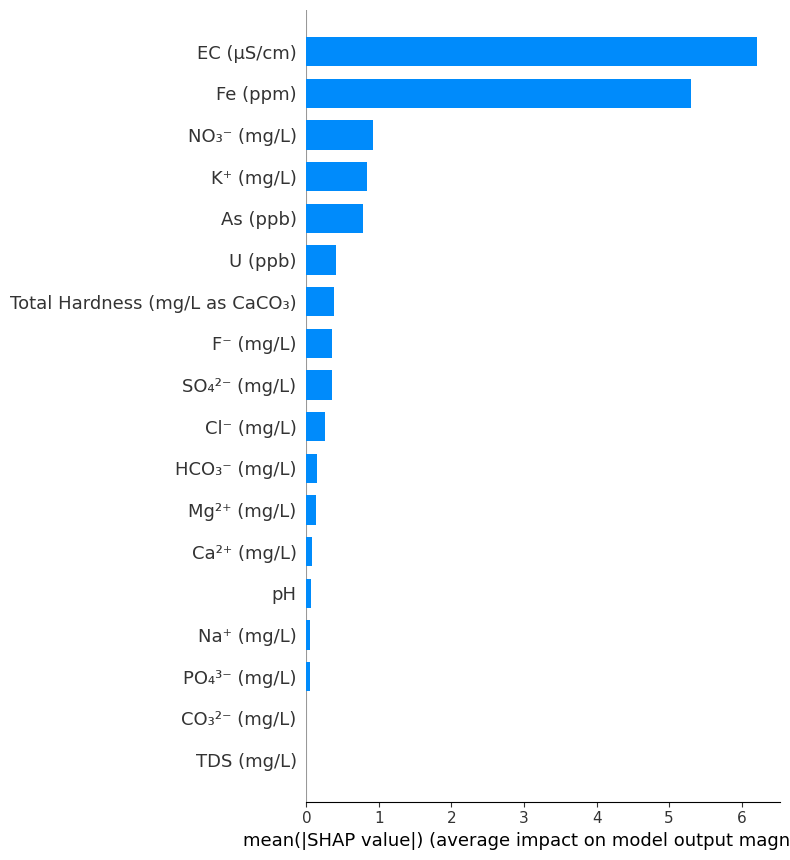

In [ ]:
# Install libraries if needed
# !pip install shap xgboost scikit-learn pandas numpy

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import shap

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Clean and prepare data
df = df.dropna(subset=features + [target])
x = df[features]
y = df[target]

# 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_xgb, mse_xgb, r2_xgb = [], [], []

model_xgb = XGBRegressor(random_state=42)

for train_idx, test_idx in kf.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model_xgb.fit(x_train, y_train)
    y_pred = model_xgb.predict(x_test)
    mae_xgb.append(mean_absolute_error(y_test, y_pred))
    mse_xgb.append(mean_squared_error(y_test, y_pred))
    r2_xgb.append(r2_score(y_test, y_pred))

print("\nXGBoost Results:")
print("MAE:", round(np.mean(mae_xgb), 3))
print("MSE:", round(np.mean(mse_xgb), 3))
print("R² Score:", round(np.mean(r2_xgb), 3))

# Refit on all data for attribution
model_xgb.fit(x, y)

# SHAP
explainer = shap.Explainer(model_xgb)
shap_values = explainer(x)
shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_weights = pd.Series(shap_importance, index=x.columns)
shap_weights_norm = shap_weights / shap_weights.sum()
print("\nNormalized SHAP-based weights:")
print(shap_weights_norm.sort_values(ascending=False))

# Permutation importance
perm = permutation_importance(model_xgb, x, y, n_repeats=10, random_state=42)
perm_importance = pd.Series(perm.importances_mean, index=x.columns)
perm_weights_norm = perm_importance / perm_importance.sum()
print("\nNormalized Permutation-based weights:")
print(perm_weights_norm.sort_values(ascending=False))

# Gain from XGB booster
booster = model_xgb.get_booster()
gain_dict = booster.get_score(importance_type='gain')
gain_series = pd.Series({col: gain_dict.get(col, 0) for col in x.columns})
gain_weights_norm = gain_series / gain_series.sum()
print("\nNormalized Gain-based weights:")
print(gain_weights_norm.sort_values(ascending=False))

# Combine
combined_weights = (shap_weights_norm + perm_weights_norm + gain_weights_norm) / 3
combined_weights = combined_weights.sort_values(ascending=False)
print("\nCombined robust feature weights for PPI:")
print(combined_weights)

# Save to CSV
combined_weights.to_csv("ppi_weights.csv")
print("\nCombined weights saved to ppi_weights.csv")

# Optional: SHAP summary plot
shap.summary_plot(shap_values.values, x, plot_type="bar", show=True)


Random Forest Results:
MAE: 2.314
MSE: 10.237
R² Score: 0.941


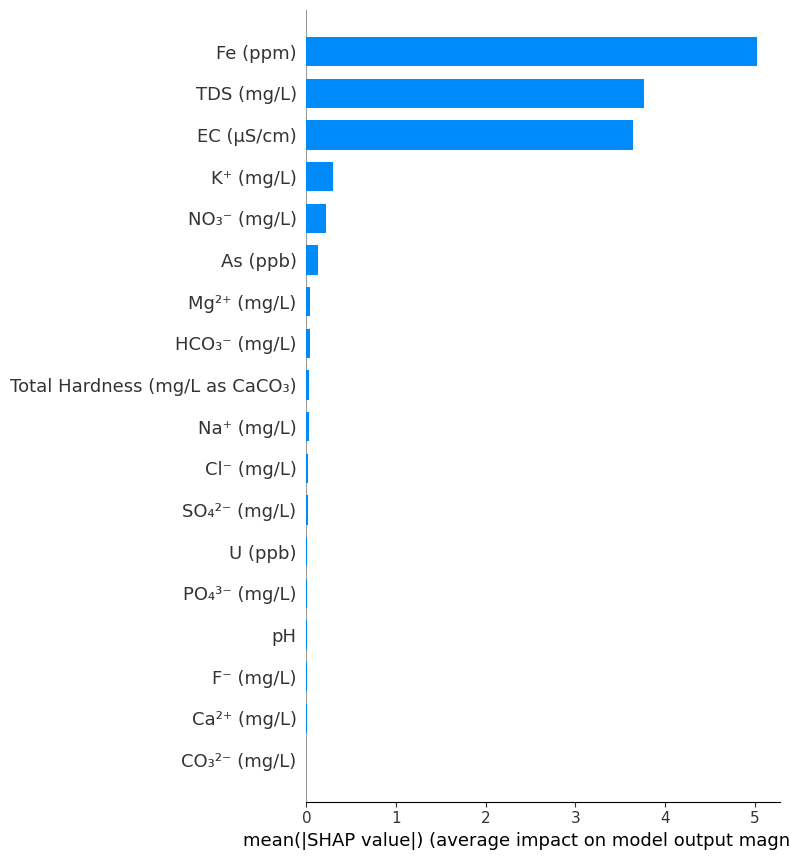

Normalized SHAP-based feature weights (for PPI):
Fe (ppm)                          0.378377
TDS (mg/L)                        0.283362
EC (µS/cm)                        0.273640
K⁺ (mg/L)                         0.022764
NO₃⁻ (mg/L)                       0.016763
As (ppb)                          0.009774
Mg²⁺ (mg/L)                       0.003118
HCO₃⁻ (mg/L)                      0.002934
Total Hardness (mg/L as CaCO₃)    0.002161
Na⁺ (mg/L)                        0.001989
Cl⁻ (mg/L)                        0.001082
SO₄²⁻ (mg/L)                      0.000985
U (ppb)                           0.000740
PO₄³⁻ (mg/L)                      0.000642
pH                                0.000583
F⁻ (mg/L)                         0.000566
Ca²⁺ (mg/L)                       0.000435
CO₃²⁻ (mg/L)                      0.000084
dtype: float64

XGBoost Results:
MAE: 1.226
MSE: 3.356
R² Score: 0.981


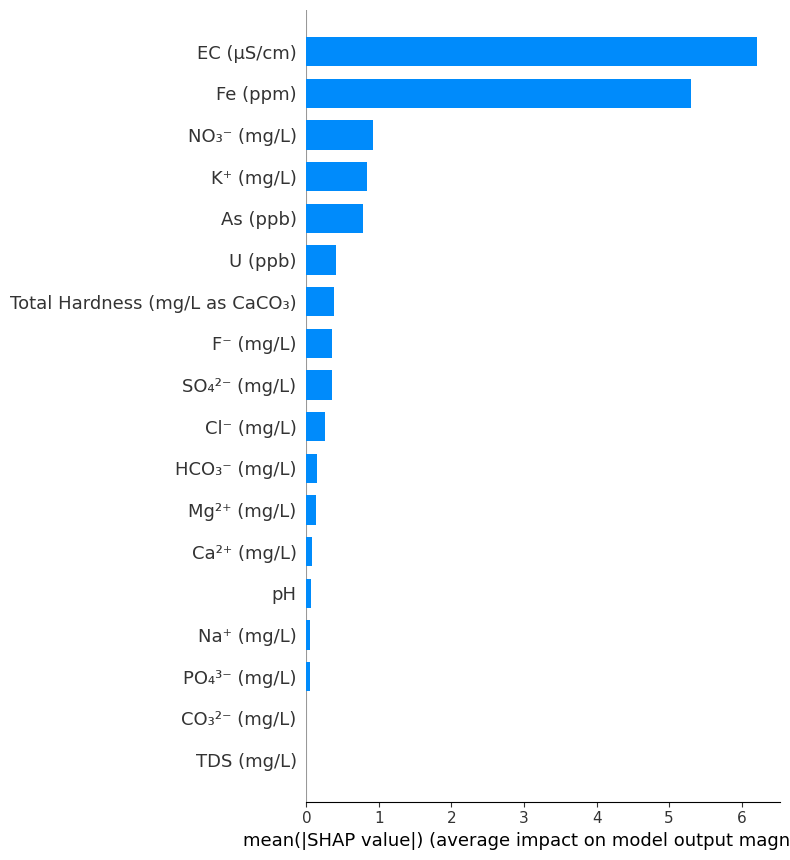

Normalized SHAP-based feature weights (for PPI):
EC (µS/cm)                        0.380767
Fe (ppm)                          0.324762
NO₃⁻ (mg/L)                       0.056329
K⁺ (mg/L)                         0.051265
As (ppb)                          0.047814
U (ppb)                           0.025180
Total Hardness (mg/L as CaCO₃)    0.023105
F⁻ (mg/L)                         0.021804
SO₄²⁻ (mg/L)                      0.021633
Cl⁻ (mg/L)                        0.016023
HCO₃⁻ (mg/L)                      0.009032
Mg²⁺ (mg/L)                       0.008199
Ca²⁺ (mg/L)                       0.004742
pH                                0.003509
Na⁺ (mg/L)                        0.003106
PO₄³⁻ (mg/L)                      0.002671
CO₃²⁻ (mg/L)                      0.000060
TDS (mg/L)                        0.000000
dtype: float32

Beeswarm Plot


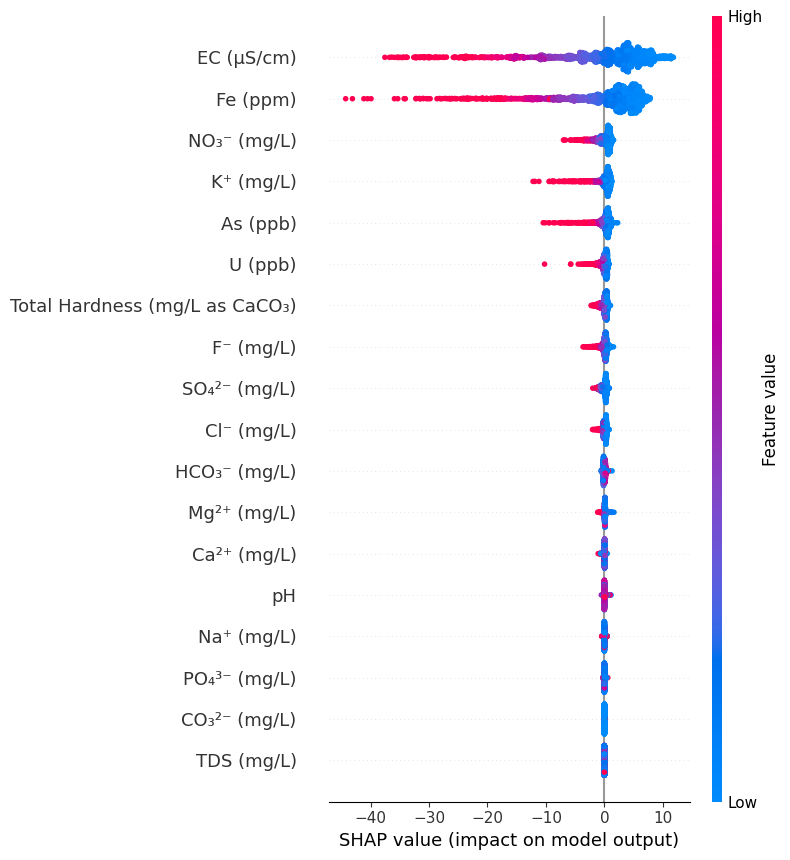

In [ ]:
#RANDOM FOREST REGRESSION
import shap
df = pd.read_csv('Ganga_River_Basin_Clean_GWQI.csv')

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Clean missing values
df = df.dropna(subset=features + [target])

# Assign x and y
x = df[features]
y = df[target]

# Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=features)

# Train Random Forest with cross-validation
model_rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_rf, mse_rf, r2_rf = [], [], []

for train_idx, test_idx in kf.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model_rf.fit(x_train, y_train)
    y_pred = model_rf.predict(x_test)
    mae_rf.append(mean_absolute_error(y_test, y_pred))
    mse_rf.append(mean_squared_error(y_test, y_pred))
    r2_rf.append(r2_score(y_test, y_pred))

print("Random Forest Results:")
print("MAE:", round(np.mean(mae_rf), 3))
print("MSE:", round(np.mean(mse_rf), 3))
print("R² Score:", round(np.mean(r2_rf), 3))

# SHAP Analysis (XGBoost)
model_rf.fit(x, y)
explainer = shap.Explainer(model_rf)
shap_values = explainer(x)

# Plot SHAP summary
shap.summary_plot(shap_values.values, x, plot_type="bar", show=True)

shap_importance = np.abs(shap_values.values).mean(axis=0)

# Convert to Series and normalize
shap_weights = pd.Series(shap_importance, index=x.columns)
shap_weights_normalized = shap_weights / shap_weights.sum()

# Sort and print
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)
print("Normalized SHAP-based feature weights (for PPI):")
print(shap_weights_normalized)

# Train XGBoost
model_xgb = XGBRegressor(random_state=42)
mae_xgb, mse_xgb, r2_xgb = [], [], []

for train_idx, test_idx in kf.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model_xgb.fit(x_train, y_train)
    y_pred = model_xgb.predict(x_test)
    mae_xgb.append(mean_absolute_error(y_test, y_pred))
    mse_xgb.append(mean_squared_error(y_test, y_pred))
    r2_xgb.append(r2_score(y_test, y_pred))

print("\nXGBoost Results:")
print("MAE:", round(np.mean(mae_xgb), 3))
print("MSE:", round(np.mean(mse_xgb), 3))
print("R² Score:", round(np.mean(r2_xgb), 3))

# SHAP Analysis (XGBoost)
model_xgb.fit(x, y)
explainer = shap.Explainer(model_xgb)
shap_values = explainer(x)

# Plot SHAP summary
shap.summary_plot(shap_values.values, x, plot_type="bar", show=True)

shap_importance = np.abs(shap_values.values).mean(axis=0)

# Convert to Series and normalize
shap_weights = pd.Series(shap_importance, index=x.columns)
shap_weights_normalized = shap_weights / shap_weights.sum()

# Sort and print
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)
print("Normalized SHAP-based feature weights (for PPI):")
print(shap_weights_normalized)
# SHAP Beeswarm Plot
print("\nBeeswarm Plot")
shap.summary_plot(shap_values, x, plot_type="dot", show=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00
CatBoost Results:
MAE: 0.655
MSE: 1.599
R² Score: 0.991


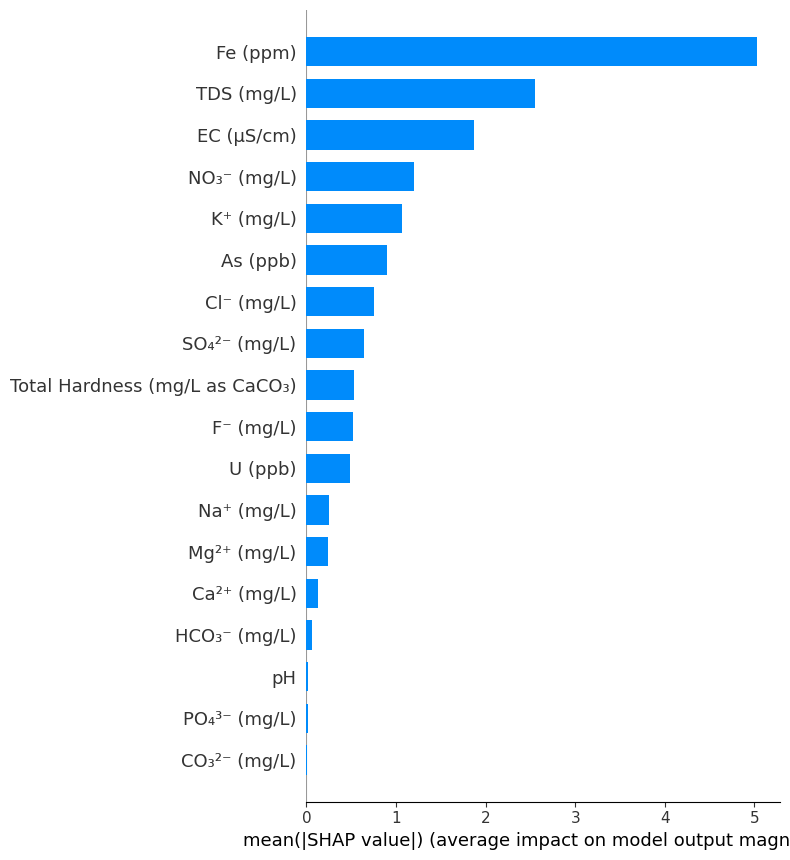


Normalized SHAP-based feature weights (CatBoost):
Fe (ppm)                          0.308846
TDS (mg/L)                        0.156737
EC (µS/cm)                        0.115125
NO₃⁻ (mg/L)                       0.073549
K⁺ (mg/L)                         0.065541
As (ppb)                          0.055388
Cl⁻ (mg/L)                        0.046140
SO₄²⁻ (mg/L)                      0.039185
Total Hardness (mg/L as CaCO₃)    0.032311
F⁻ (mg/L)                         0.031649
U (ppb)                           0.030056
Na⁺ (mg/L)                        0.015242
Mg²⁺ (mg/L)                       0.015002
Ca²⁺ (mg/L)                       0.007977
HCO₃⁻ (mg/L)                      0.004100
pH                                0.001352
PO₄³⁻ (mg/L)                      0.001177
CO₃²⁻ (mg/L)                      0.000622
dtype: float64

Beeswarm Plot


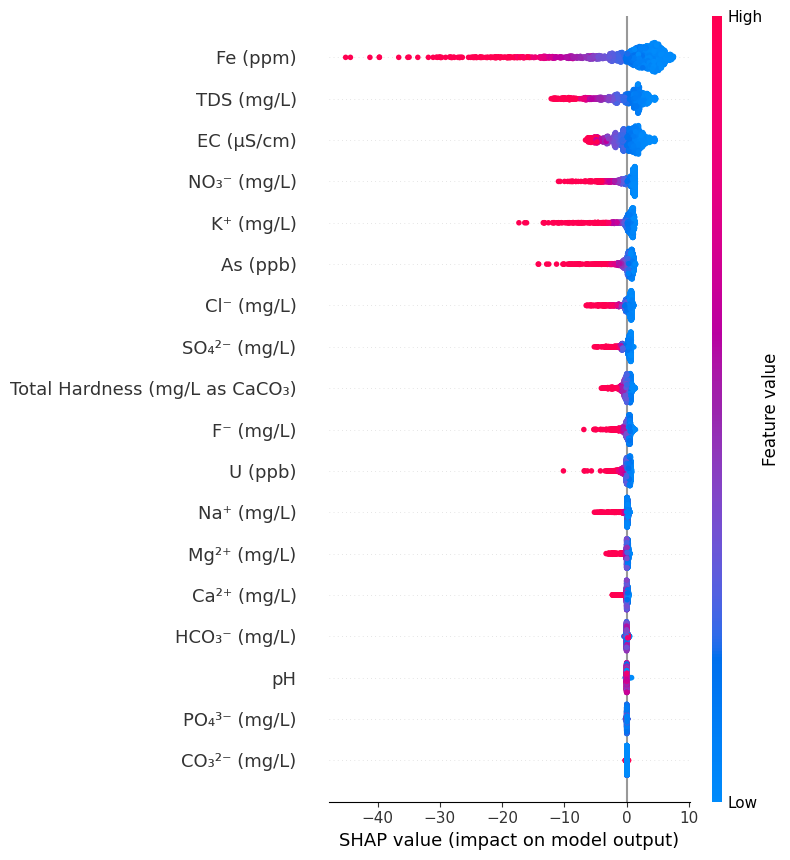

In [ ]:
#CatBOOST Regression
!pip install catboost
from catboost import CatBoostRegressor
import shap

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Clean and prepare data
df = df.dropna(subset=features + [target])
x = df[features]
y = df[target]

# Scale the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=features)

# Train CatBoost with 5-Fold CV
model_cb = CatBoostRegressor(verbose=0, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_cb, mse_cb, r2_cb = [], [], []

for train_idx, test_idx in kf.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model_cb.fit(x_train, y_train)
    y_pred = model_cb.predict(x_test)
    mae_cb.append(mean_absolute_error(y_test, y_pred))
    mse_cb.append(mean_squared_error(y_test, y_pred))
    r2_cb.append(r2_score(y_test, y_pred))

print("CatBoost Results:")
print("MAE:", round(np.mean(mae_cb), 3))
print("MSE:", round(np.mean(mse_cb), 3))
print("R² Score:", round(np.mean(r2_cb), 3))

# SHAP Analysis
model_cb.fit(x, y)
explainer = shap.Explainer(model_cb)
shap_values = explainer(x)

shap.summary_plot(shap_values.values, x, plot_type="bar", show=True)

# Normalized SHAP weights
shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_weights = pd.Series(shap_importance, index=x.columns)
shap_weights_normalized = shap_weights / shap_weights.sum()
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)

print("\nNormalized SHAP-based feature weights (CatBoost):")
print(shap_weights_normalized)
# SHAP Beeswarm Plot
print("\nBeeswarm Plot")
shap.summary_plot(shap_values, x, plot_type="dot", show=True)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Optimized Extra Trees Results:
MAE: 2.035
MSE: 7.775
R² Score: 0.955

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


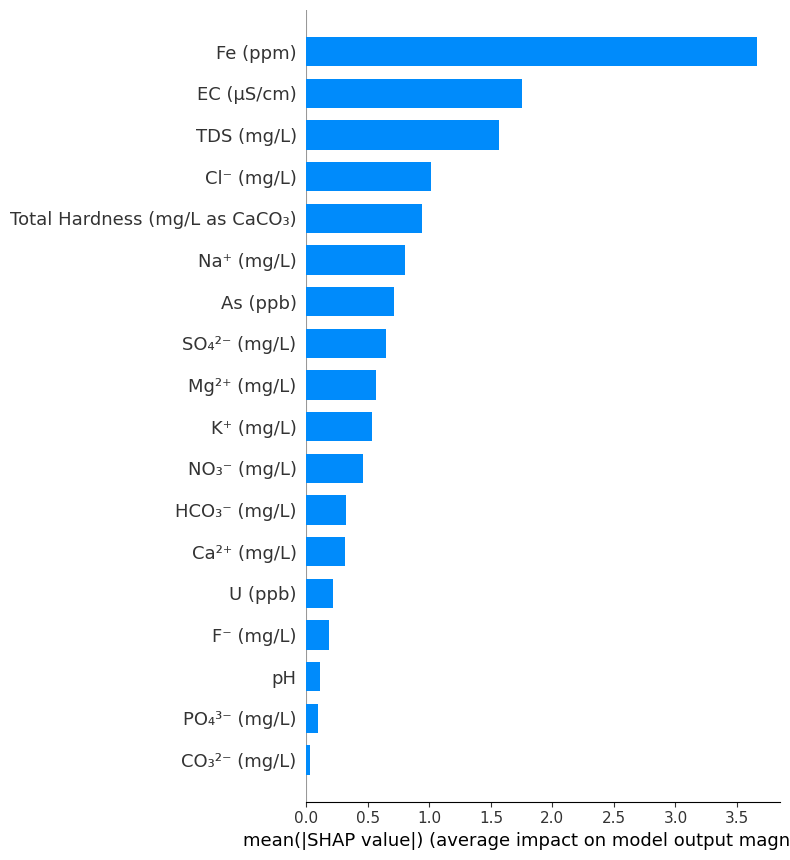


Normalized SHAP Feature Weights:
Fe (ppm)                          0.263423
EC (µS/cm)                        0.125826
TDS (mg/L)                        0.112215
Cl⁻ (mg/L)                        0.072929
Total Hardness (mg/L as CaCO₃)    0.067377
Na⁺ (mg/L)                        0.057388
As (ppb)                          0.051423
SO₄²⁻ (mg/L)                      0.046226
Mg²⁺ (mg/L)                       0.040749
K⁺ (mg/L)                         0.038119
NO₃⁻ (mg/L)                       0.033372
HCO₃⁻ (mg/L)                      0.022891
Ca²⁺ (mg/L)                       0.022572
U (ppb)                           0.015814
F⁻ (mg/L)                         0.013173
pH                                0.007748
PO₄³⁻ (mg/L)                      0.006591
CO₃²⁻ (mg/L)                      0.002166
dtype: float64

Beeswarm Plot


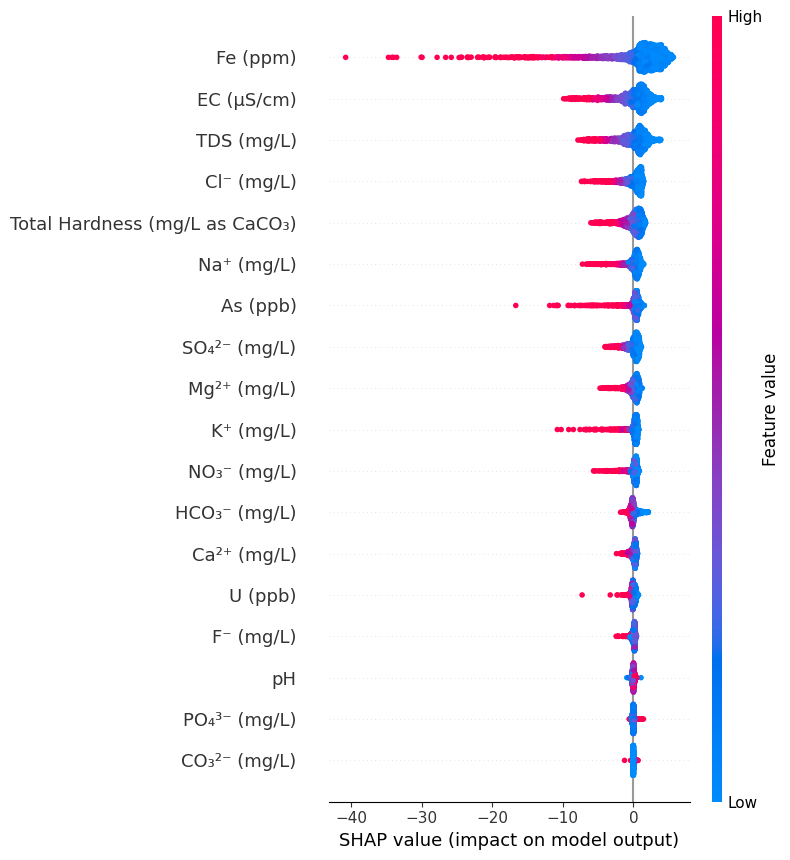

In [ ]:
#Extra Trees Regression
from sklearn.ensemble import ExtraTreesRegressor
import shap
import pandas as pd
df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Preprocess
df = df.dropna(subset=features + [target])
x = df[features]
y = df[target]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=features)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

et = ExtraTreesRegressor(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=et, param_grid=param_grid,
                           scoring='r2', cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(x, y)

best_et = grid_search.best_estimator_

# Cross-validated metrics
mae_list, mse_list, r2_list = [], [], []

for train_idx, test_idx in cv.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    best_et.fit(x_train, y_train)
    y_pred = best_et.predict(x_test)
    mae_list.append(mean_absolute_error(y_test, y_pred))
    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

print("Optimized Extra Trees Results:")
print("MAE:", round(np.mean(mae_list), 3))
print("MSE:", round(np.mean(mse_list), 3))
print("R² Score:", round(np.mean(r2_list), 3))
print("\nBest Parameters:", grid_search.best_params_)

# SHAP for feature weights
best_et.fit(x, y)
explainer = shap.Explainer(best_et)
shap_values = explainer(x)

# Plot
shap.summary_plot(shap_values.values, x, plot_type="bar", show=True)

# Normalized SHAP weights
shap_mean = np.abs(shap_values.values).mean(axis=0)
shap_weights = pd.Series(shap_mean, index=features)
shap_weights_normalized = shap_weights / shap_weights.sum()
print("\nNormalized SHAP Feature Weights:")
print(shap_weights_normalized.sort_values(ascending=False))
#CatBoost Beeswarm
# SHAP Beeswarm Plot
print("\nBeeswarm Plot")
shap.summary_plot(shap_values, x, plot_type="dot", show=True)

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,7 mins 52 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,3 months and 17 days
H2O_cluster_name:,H2O_from_python_unknownUser_vfjbu9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.973 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O Random Forest Evaluation:
RMSE: 3.2866
MAE: 2.2142
R² Score: 0.9404
Explained Variance: 0.9407
MAPE: 5.12%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


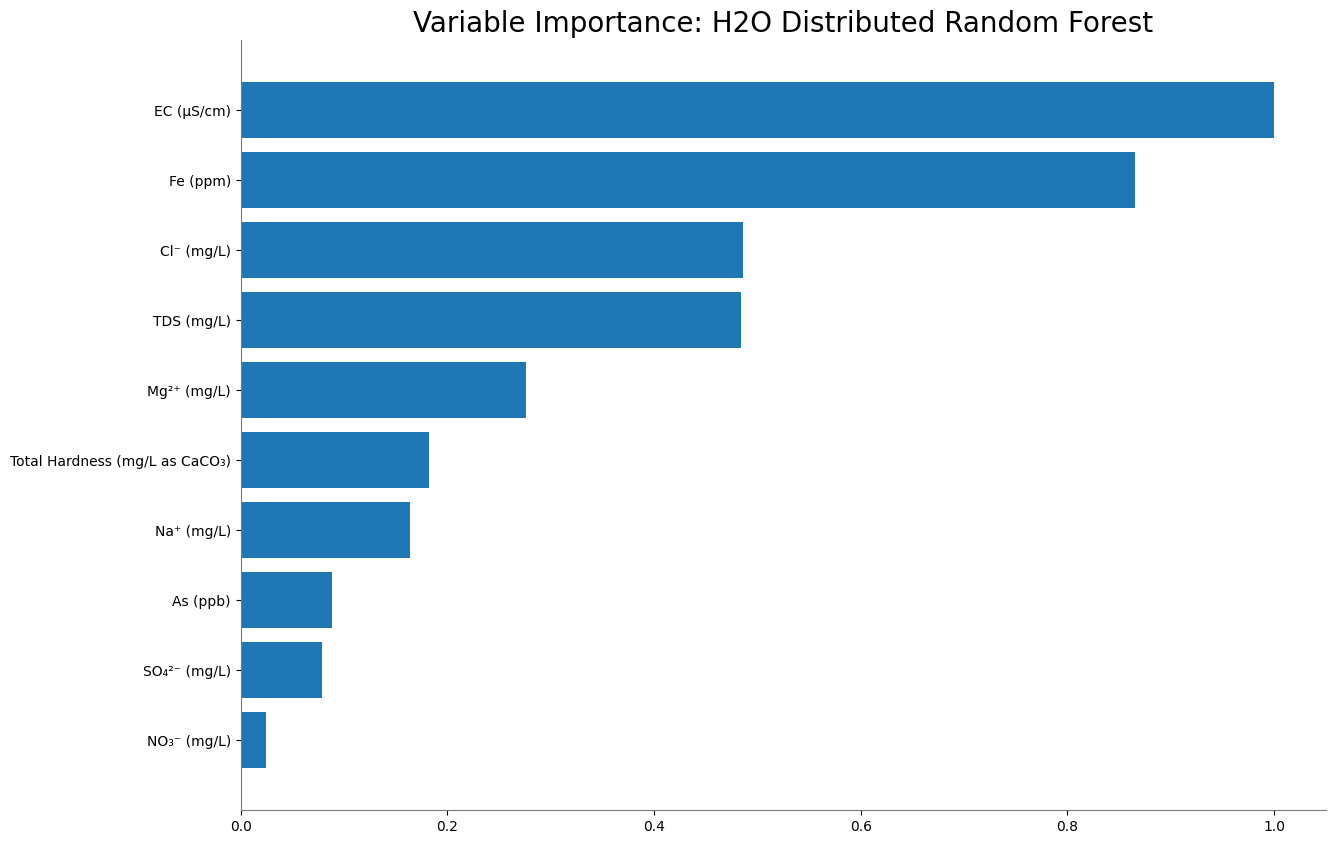

Normalized H2O Feature Weights (for PPI):
                          variable  NormalizedWeight
0                       EC (µS/cm)          0.266514
1                         Fe (ppm)          0.230745
2                       Cl⁻ (mg/L)          0.129616
3                       TDS (mg/L)          0.129153
4                      Mg²⁺ (mg/L)          0.073606
5   Total Hardness (mg/L as CaCO₃)          0.048644
6                       Na⁺ (mg/L)          0.043559
7                         As (ppb)          0.023530
8                     SO₄²⁻ (mg/L)          0.021068
9                      NO₃⁻ (mg/L)          0.006629
10                    HCO₃⁻ (mg/L)          0.005811
11                       K⁺ (mg/L)          0.005734
12                       F⁻ (mg/L)          0.005485
13                     Ca²⁺ (mg/L)          0.004274
14                         U (ppb)          0.002613
15                    PO₄³⁻ (mg/L)          0.001629
16                              pH          0.001388
17  

<Figure size 640x480 with 0 Axes>

In [ ]:
#H2O Random Forest
import h2o
from h2o.estimators import H2ORandomForestEstimator
from sklearn.metrics import explained_variance_score

# Start H2O Cluster
h2o.init(max_mem_size="4G")

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

# Drop non-feature columns
df = df.drop(columns=['S. No.', 'State', 'District', 'Location', 'Latitude', 'Longitude', 'Year'])

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Drop rows with missing values in required columns
df = df.dropna(subset=features + [target])

# Convert to H2OFrame
df_h2o = h2o.H2OFrame(df)

# Split into training and test sets
train, test = df_h2o.split_frame(ratios=[0.7], seed=123)

# Train H2O Random Forest model
rf_model = H2ORandomForestEstimator(
    ntrees=200,
    max_depth=20,
    min_rows=5,
    seed=123,
    stopping_rounds=5,
    stopping_metric="RMSE",
    score_each_iteration=True
)
rf_model.train(x=features, y=target, training_frame=train, validation_frame=test)

# Make predictions
preds = rf_model.predict(test).as_data_frame().values.ravel()
actual = test[target].as_data_frame().values.ravel()

# Evaluate model
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
explained_var = explained_variance_score(actual, preds)
mape = np.mean(np.abs((actual - preds) / actual)) * 100

# Print results
print("H2O Random Forest Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")
print(f"MAPE: {mape:.2f}%")

# Plot feature importance
rf_model.varimp_plot()

# Get variable importance as DataFrame
varimp = rf_model.varimp(use_pandas=True)

# Normalize the 'scaled_importance' column to sum to 1
varimp['NormalizedWeight'] = varimp['scaled_importance'] / varimp['scaled_importance'].sum()

# Sort descending by weight
varimp_sorted = varimp.sort_values(by="NormalizedWeight", ascending=False)

# Display results
print("Normalized H2O Feature Weights (for PPI):")
print(varimp_sorted[['variable', 'NormalizedWeight']])


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,10 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,3 months and 17 days
H2O_cluster_name:,H2O_from_python_unknownUser_vfjbu9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4.000 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm Grid Build progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


H2O GBM Performance:
RMSE: 1.4889
MAE: 1.0043
R² Score: 0.9878
Explained Variance: 0.9878
MAPE: 2.30%

Best Hyperparameters:
{'model_id': None, 'training_frame': None, 'validation_frame': None, 'nfolds': 0, 'keep_cross_validation_models': True, 'keep_cross_validation_predictions': False, 'keep_cross_validation_fold_assignment': False, 'score_each_iteration': False, 'score_tree_interval': 0, 'fold_assignment': 'auto', 'fold_column': None, 'response_column': None, 'ignored_columns': None, 'ignore_const_cols': True, 'offset_column': None, 'weights_column': None, 'balance_classes': False, 'class_sampling_factors': None, 'max_after_balance_size': 5.0, 'max_confusion_matrix_size': 20, 'ntrees': 50, 'max_depth': 5, 'min_rows': 10.0, 'nbins': 20, 'nbins_top_level': 1024, 'nbins_cats': 1024, 'r2_stopping': None, 'stopping_rounds': 0, 'stopping_metric': 'auto', 'stopping_tolerance': 0.001, 'max_runtime_secs': 0.0, 'seed': -1, 'build_tree_one_node': False, 'learn_rate': 0.1, 'learn_rate_annealing

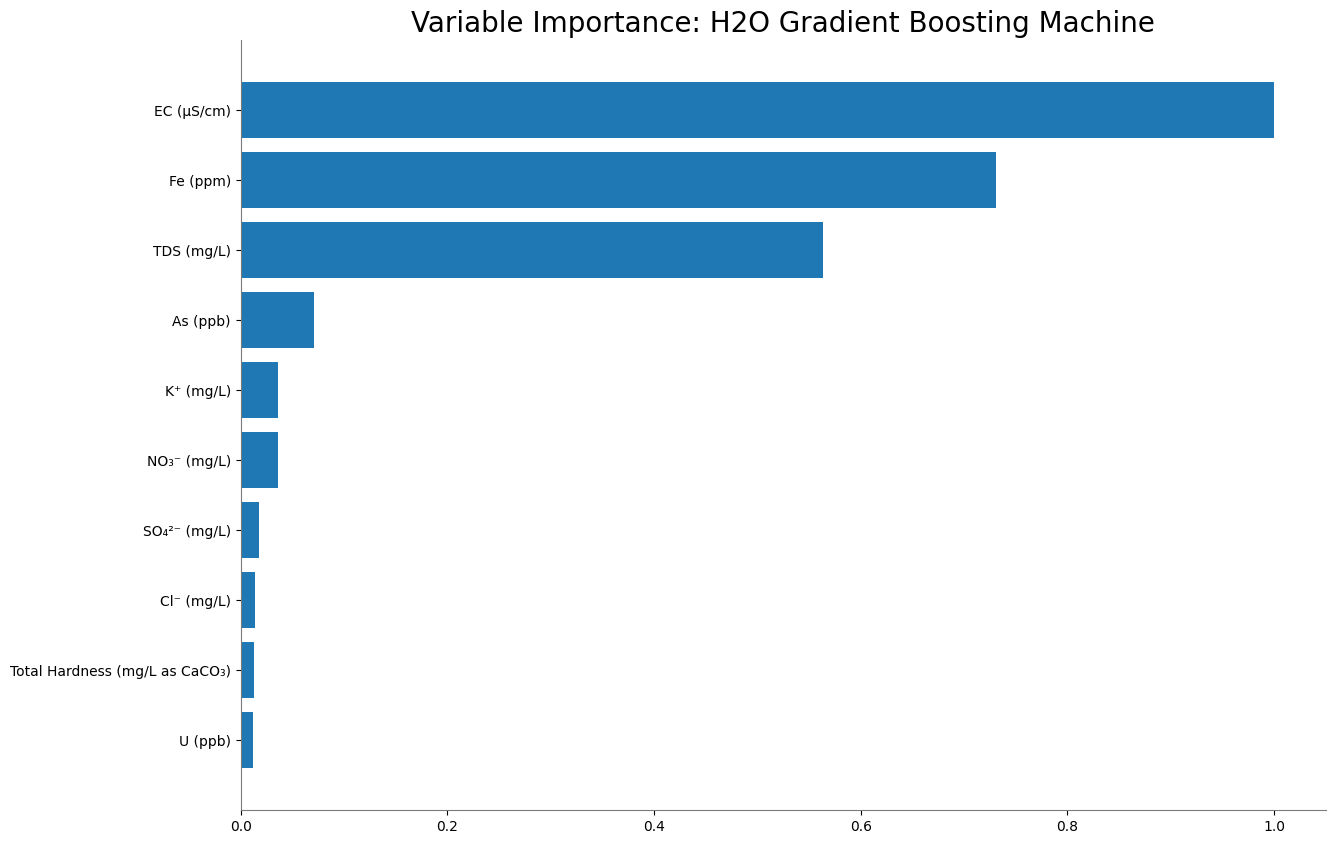

Normalized GBM Feature Weights (for PPI):
                          variable  NormalizedWeight
0                       EC (µS/cm)          0.396961
1                         Fe (ppm)          0.290131
2                       TDS (mg/L)          0.223508
3                         As (ppb)          0.028337
4                        K⁺ (mg/L)          0.014377
5                      NO₃⁻ (mg/L)          0.014230
6                     SO₄²⁻ (mg/L)          0.006941
7                       Cl⁻ (mg/L)          0.005625
8   Total Hardness (mg/L as CaCO₃)          0.004984
9                          U (ppb)          0.004729
10                       F⁻ (mg/L)          0.004546
11                     Mg²⁺ (mg/L)          0.001929
12                     Ca²⁺ (mg/L)          0.001003
13                    HCO₃⁻ (mg/L)          0.000850
14                      Na⁺ (mg/L)          0.000736
15                              pH          0.000691
16                    PO₄³⁻ (mg/L)          0.000414
17  

<Figure size 640x480 with 0 Axes>

In [ ]:
#H2O GBM
import h2o
from h2o.grid.grid_search import H2OGridSearch
from h2o.estimators import H2OGradientBoostingEstimator
from sklearn.metrics import explained_variance_score

# Start H2O cluster
h2o.init(max_mem_size="4G")

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

# Drop non-feature columns
df = df.drop(columns=['S. No.', 'State', 'District', 'Location', 'Latitude', 'Longitude', 'Year'])

target = "GWQI (0–100 Index)"
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]

# Drop rows with missing data
df = df.dropna(subset=features + [target])

# Convert to H2OFrame
df_h2o = h2o.H2OFrame(df)

# Split into training and test sets
train, test = df_h2o.split_frame(ratios=[0.7], seed=123)

# Define hyperparameter grid
hyper_params = {
    'ntrees': [100, 200],
    'max_depth': [4, 6, 8],
    'learn_rate': [0.05, 0.1],
    'sample_rate': [0.8, 1.0],
    'col_sample_rate': [0.8, 1.0]
}

# Set up GBM estimator
gbm = H2OGradientBoostingEstimator(
    stopping_rounds=5,
    stopping_metric="RMSE",
    seed=123,
    score_each_iteration=True
)

# Train using grid search
grid = H2OGridSearch(model=gbm, hyper_params=hyper_params, grid_id="gbm_grid")
grid.train(x=features, y=target, training_frame=train, validation_frame=test)

# Get best model
best_gbm = grid.get_grid(sort_by='rmse', decreasing=False).models[0]

# Evaluate model
preds = best_gbm.predict(test).as_data_frame().values.ravel()
actual = test[target].as_data_frame().values.ravel()

rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
explained_var = explained_variance_score(actual, preds)
mape = np.mean(np.abs((actual - preds) / actual)) * 100

# Print metrics
print("H2O GBM Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")
print(f"MAPE: {mape:.2f}%")

# Show best parameters
print("\nBest Hyperparameters:")
print(best_gbm.get_params())

# Plot feature importance
best_gbm.varimp_plot()

# Feature Importance for PPI
varimp = best_gbm.varimp(use_pandas=True)
varimp['NormalizedWeight'] = varimp['scaled_importance'] / varimp['scaled_importance'].sum()
varimp_sorted = varimp.sort_values(by="NormalizedWeight", ascending=False)

print("Normalized GBM Feature Weights (for PPI):")
print(varimp_sorted[['variable', 'NormalizedWeight']])


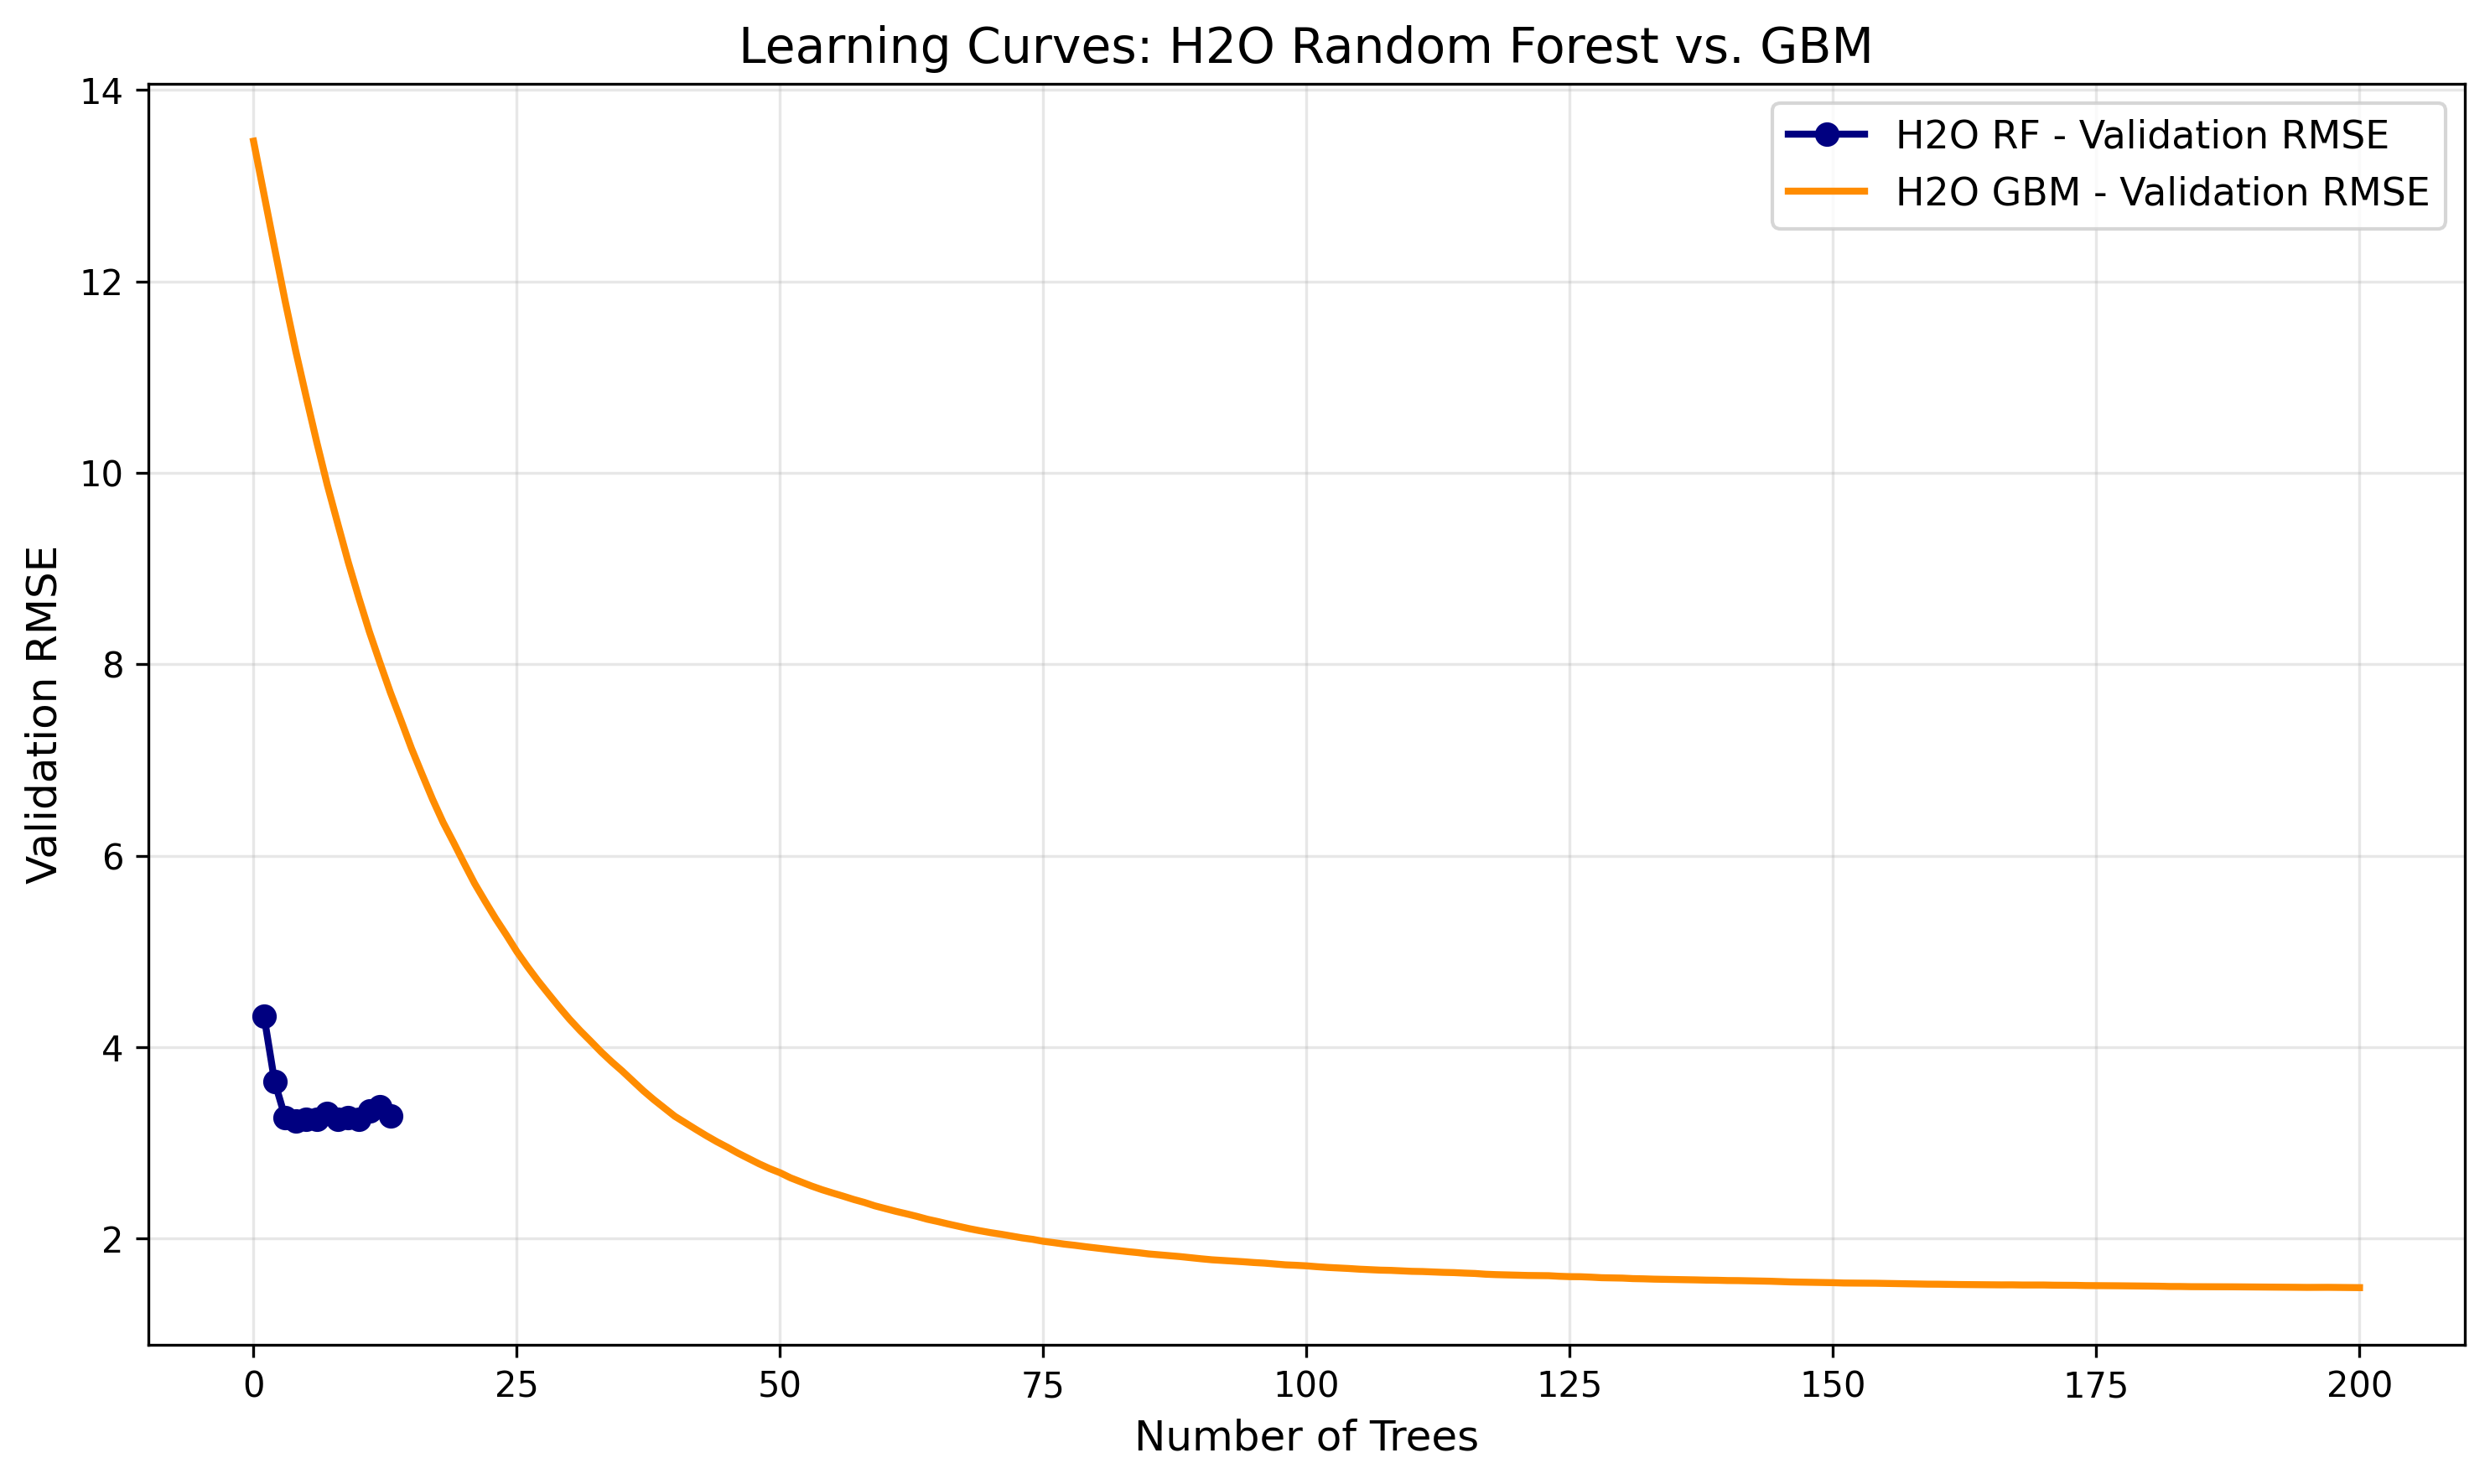

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(rf_hist['number_of_trees'], rf_hist['validation_rmse'],
         label='H2O RF - Validation RMSE', color='navy', linewidth=2, marker='o')
plt.plot(gbm_hist['number_of_trees'], gbm_hist['validation_rmse'],
         label='H2O GBM - Validation RMSE', color='darkorange', linewidth=2)

plt.xlabel("Number of Trees", fontsize=12)
plt.ylabel("Validation RMSE", fontsize=12)
plt.title("Learning Curves: H2O Random Forest vs. GBM", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve_rf_vs_gbm.png", dpi=300)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


MLP Regressor (ANN) Results:
MAE: 0.629
MSE: 1.274
R² Score: 0.993


PermutationExplainer explainer: 1800it [02:59, 10.03it/s]                          
/tmp/ipython-input-9-2249897215.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_array, x, plot_type="bar", show=True)



Normalized SHAP Feature Weights (for PPI):
Fe (ppm)                          0.276656
EC (µS/cm)                        0.082440
NO₃⁻ (mg/L)                       0.079638
Na⁺ (mg/L)                        0.076790
TDS (mg/L)                        0.071082
As (ppb)                          0.057091
K⁺ (mg/L)                         0.056114
Cl⁻ (mg/L)                        0.052516
Total Hardness (mg/L as CaCO₃)    0.042321
F⁻ (mg/L)                         0.040155
Mg²⁺ (mg/L)                       0.032390
SO₄²⁻ (mg/L)                      0.032142
Ca²⁺ (mg/L)                       0.028828
U (ppb)                           0.027864
CO₃²⁻ (mg/L)                      0.015948
pH                                0.011132
HCO₃⁻ (mg/L)                      0.010471
PO₄³⁻ (mg/L)                      0.006422
dtype: float64


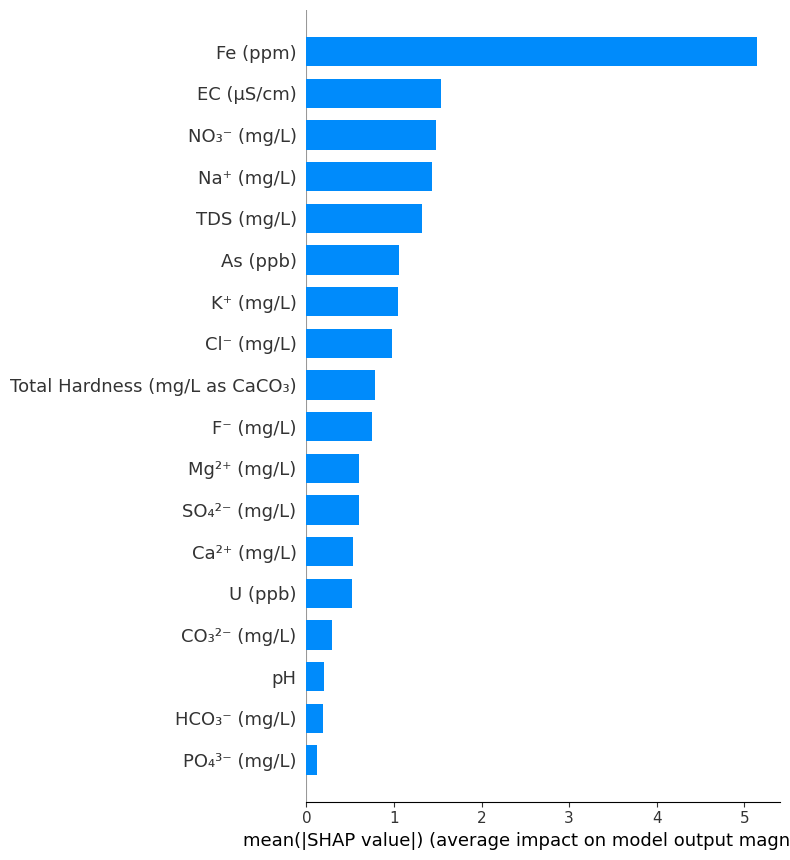

In [ ]:
#MultiLayer Perceptron ANN
from sklearn.neural_network import MLPRegressor
import shap

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

# Define Features and Target
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Preprocess
df = df.dropna(subset=features + [target])
x = df[features]
y = df[target]

# Impute
imputer = SimpleImputer(strategy='mean')
x_imputed = imputer.fit_transform(x)
x = pd.DataFrame(x_imputed, columns=features)

# Scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=features)

# Model
model_ann = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', alpha=0.001, learning_rate='adaptive',
                         max_iter=500, random_state=42)

# Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_list, mse_list, r2_list = [], [], []

for train_idx, test_idx in kf.split(x):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model_ann.fit(x_train, y_train)
    y_pred = model_ann.predict(x_test)
    mae_list.append(mean_absolute_error(y_test, y_pred))
    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

print("\nMLP Regressor (ANN) Results:")
print("MAE:", round(np.mean(mae_list), 3))
print("MSE:", round(np.mean(mse_list), 3))
print("R² Score:", round(np.mean(r2_list), 3))

# SHAP Analysis
explainer = shap.Explainer(model_ann.predict, x)
shap_values = explainer(x)

# Ensure SHAP values are aligned correctly
if hasattr(shap_values, 'values'):
    shap_array = shap_values.values
else:
    shap_array = shap_values

if shap_array.ndim == 1:
    shap_array = shap_array.reshape(1, -1)

shap_mean = np.abs(shap_array).mean(axis=0)
shap_weights = pd.Series(shap_mean, index=features)
shap_weights_normalized = shap_weights / shap_weights.sum()

# Final Output
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)
print("\nNormalized SHAP Feature Weights (for PPI):")
print(shap_weights_normalized)

shap.summary_plot(shap_array, x, plot_type="bar", show=True)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


Stacking Ensemble Results:
MAE: 0.533
MSE: 0.864
R² Score: 0.995


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro


Normalized SHAP Feature Weights (for PPI from Stacked Model):
Fe (ppm)                          0.274087
EC (µS/cm)                        0.100216
NO₃⁻ (mg/L)                       0.074367
Cl⁻ (mg/L)                        0.074285
TDS (mg/L)                        0.071912
Mg²⁺ (mg/L)                       0.058622
K⁺ (mg/L)                         0.052874
As (ppb)                          0.052094
Ca²⁺ (mg/L)                       0.044934
Na⁺ (mg/L)                        0.041338
SO₄²⁻ (mg/L)                      0.037405
F⁻ (mg/L)                         0.036770
U (ppb)                           0.033533
Total Hardness (mg/L as CaCO₃)    0.023185
CO₃²⁻ (mg/L)                      0.011212
HCO₃⁻ (mg/L)                      0.006767
pH                                0.004125
PO₄³⁻ (mg/L)                      0.002274
dtype: float64


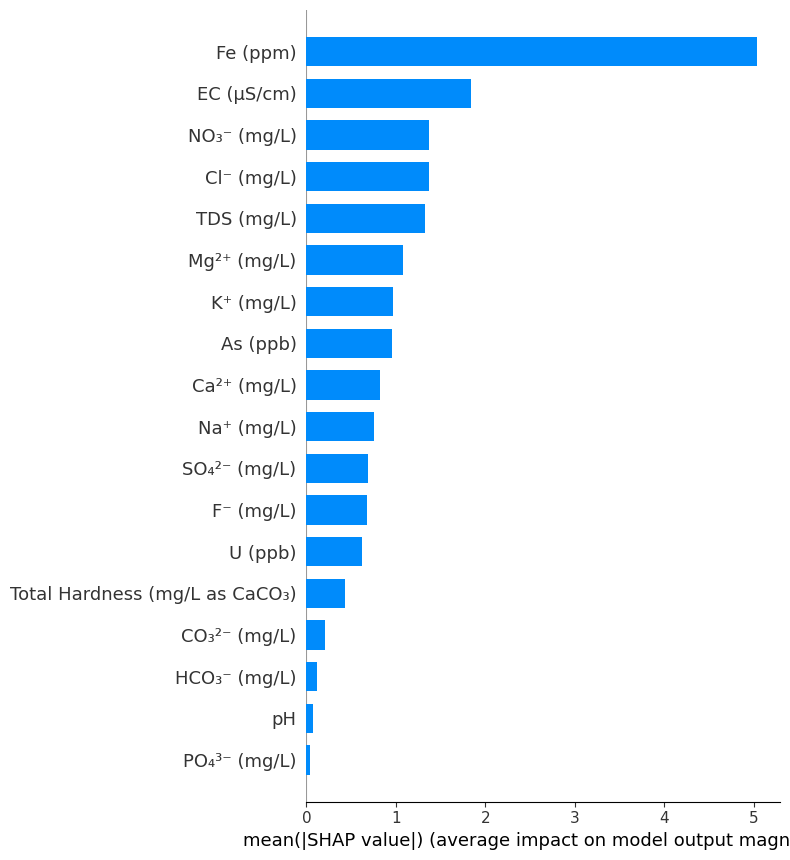


Beeswarm Plot


/tmp/ipython-input-3-1925782246.py:83: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled, plot_type="dot", show=True)


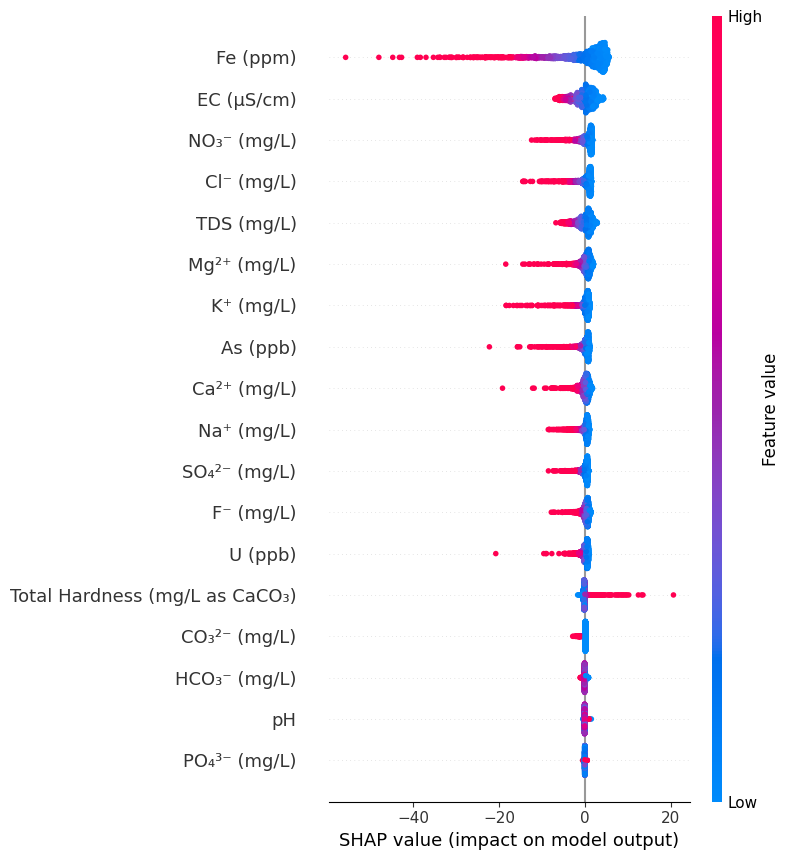

In [ ]:
#Stacked Ensemble
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
!pip install catboost
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
import shap

# Load dataset
df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

# Preprocess
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# Define Base Models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)),
    ('cat', CatBoostRegressor(verbose=0, random_state=42)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=100, random_state=42))
]

# Define Meta Learner
meta_model = Ridge()

# Build Stacking Regressor
stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True
)

# Train and Evaluate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_list, mse_list, r2_list = [], [], []

for train_idx, test_idx in kf.split(X_scaled):
    x_train, x_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    stack.fit(x_train, y_train)
    y_pred = stack.predict(x_test)
    mae_list.append(mean_absolute_error(y_test, y_pred))
    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

print("\nStacking Ensemble Results:")
print("MAE:", round(np.mean(mae_list), 3))
print("MSE:", round(np.mean(mse_list), 3))
print("R² Score:", round(np.mean(r2_list), 3))

# SHAP Importance
stack.fit(X_scaled, y)
explainer = shap.Explainer(stack.predict, X_scaled)
shap_values = explainer(X_scaled)
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Normalize and display
shap_weights = pd.Series(shap_importance, index=features)
shap_weights_normalized = shap_weights / shap_weights.sum()
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)

print("\nNormalized SHAP Feature Weights (for PPI from Stacked Model):")
print(shap_weights_normalized)
shap.summary_plot(shap_values, X_scaled, plot_type="bar", show=True)
# SHAP Beeswarm Plot
print("\nBeeswarm Plot")
shap.summary_plot(shap_values, X_scaled, plot_type="dot", show=True)

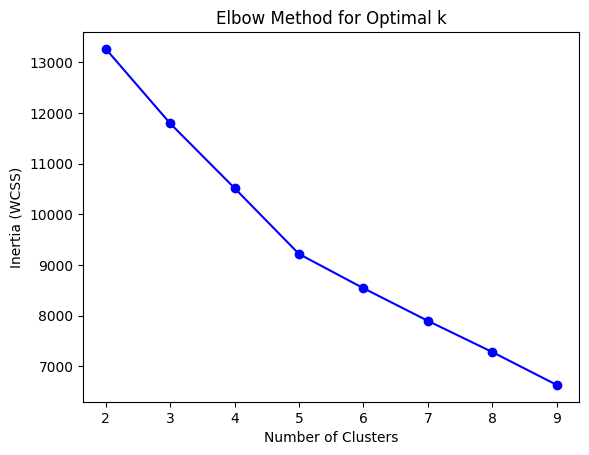


Cluster-wise Mean Pollutant Levels:
         Fe (ppm)  As (ppb)    U (ppb)  NO₃⁻ (mg/L)  PO₄³⁻ (mg/L)  \
Cluster                                                             
0        1.330688  7.333039  10.121077    16.228142      0.177486   
1        0.307743  1.364430  26.935333   161.377778      0.179267   
2        0.330814  3.294706  11.323075    19.636364      1.527312   
3        0.400124  2.670978  29.384548    60.314554      0.199280   

          Cl⁻ (mg/L)  F⁻ (mg/L)  SO₄²⁻ (mg/L)   TDS (mg/L)   EC (µS/cm)  
Cluster                                                                  
0          75.088115   0.575362     35.605874   567.980123   873.815574  
1        2108.022222   1.262889    970.422222  6054.793333  9315.066667  
2          92.038961   1.005195     27.636364   586.316883   902.025974  
3         502.577465   1.695775    261.046948  1937.238028  2980.366197  


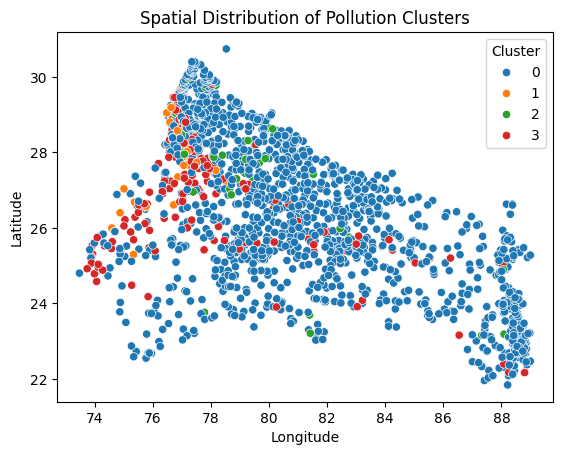

In [ ]:
#K Means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Ganga_River_Basin_Clean_GWQI.csv")

pollutants = [
    "Fe (ppm)", "As (ppb)", "U (ppb)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)",
    "Cl⁻ (mg/L)", "F⁻ (mg/L)", "SO₄²⁻ (mg/L)", "TDS (mg/L)", "EC (µS/cm)"
]

# Convert to numeric, clean
df[pollutants] = df[pollutants].apply(pd.to_numeric, errors='coerce')
df_poll = df[pollutants].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_poll)

# Elbow method to choose k
inertia = []
K = range(2, 10)
for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Choose k and fit final model
k = 4  # based on elbow curve
kmeans = KMeans(n_clusters=k, random_state=42)
df_poll['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster profiles
cluster_means = df_poll.groupby('Cluster').mean()
print("\nCluster-wise Mean Pollutant Levels:")
print(cluster_means)

# Add lat/lon for mapping
df_result = df.loc[df_poll.index, ['Latitude', 'Longitude']]
df_result['Cluster'] = df_poll['Cluster']

# Visualize 2D clusters
sns.scatterplot(data=df_result, x="Longitude", y="Latitude", hue="Cluster", palette='tab10')
plt.title("Spatial Distribution of Pollution Clusters")
plt.show()


In [ ]:
#RANDOM FOREST (Train on GRB excluding VRB, Test on VRB)
grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Clean data
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# Split
x_train = grb[features]
y_train = grb[target]
x_test = vrb[features]
y_test = vrb[target]

# Scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Random Forest
model_rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
model_rf.fit(x_train_scaled, y_train)

# Predict on VRB
y_pred = model_rf.predict(x_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest (Trained on GRB excl. VRB → Tested on VRB):")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R² Score:", round(r2, 3))

# Feature Weights for PPI
importances = model_rf.feature_importances_
rf_weights = pd.Series(importances, index=features)
rf_weights_normalized = rf_weights / rf_weights.sum()

print("\nNormalized Random Forest Feature Weights (for PPI):")
print(rf_weights_normalized.sort_values(ascending=False))


Random Forest (Trained on GRB excl. VRB → Tested on VRB):
MAE: 2.291
MSE: 8.062
R² Score: 0.774

Normalized Random Forest Feature Weights (for PPI):
Fe (ppm)                          0.355189
TDS (mg/L)                        0.320424
EC (µS/cm)                        0.300223
K⁺ (mg/L)                         0.009205
NO₃⁻ (mg/L)                       0.004926
As (ppb)                          0.004293
Mg²⁺ (mg/L)                       0.000942
Total Hardness (mg/L as CaCO₃)    0.000846
HCO₃⁻ (mg/L)                      0.000783
Cl⁻ (mg/L)                        0.000539
U (ppb)                           0.000444
Ca²⁺ (mg/L)                       0.000429
PO₄³⁻ (mg/L)                      0.000425
SO₄²⁻ (mg/L)                      0.000422
Na⁺ (mg/L)                        0.000409
pH                                0.000247
F⁻ (mg/L)                         0.000180
CO₃²⁻ (mg/L)                      0.000073
dtype: float64


In [ ]:
#XGBOOST (Train on GRB excluding VRB, Test on VRB)
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

# Feature columns and target
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Drop missing values
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# Assign features and targets
x_train = grb[features]
y_train = grb[target]
x_test = vrb[features]
y_test = vrb[target]

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train XGBoost model
model_xgb = XGBRegressor(random_state=42, n_estimators=100, max_depth=6, learning_rate=0.1)
model_xgb.fit(x_train_scaled, y_train)

# Predict on VRB
y_pred = model_xgb.predict(x_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost (Trained on GRB excl. VRB → Tested on VRB):")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R² Score:", round(r2, 3))

# Feature importance
xgb_weights = pd.Series(model_xgb.feature_importances_, index=features)
xgb_weights_normalized = xgb_weights / xgb_weights.sum()

print("\nNormalized XGBoost Feature Weights (for PPI):")
print(xgb_weights_normalized.sort_values(ascending=False))


XGBoost (Trained on GRB excl. VRB → Tested on VRB):
MAE: 0.897
MSE: 1.493
R² Score: 0.958

Normalized XGBoost Feature Weights (for PPI):
EC (µS/cm)                        0.569791
Fe (ppm)                          0.309933
K⁺ (mg/L)                         0.023518
NO₃⁻ (mg/L)                       0.020961
As (ppb)                          0.015454
Mg²⁺ (mg/L)                       0.013062
SO₄²⁻ (mg/L)                      0.009899
Cl⁻ (mg/L)                        0.009885
Total Hardness (mg/L as CaCO₃)    0.008639
U (ppb)                           0.007874
F⁻ (mg/L)                         0.004206
HCO₃⁻ (mg/L)                      0.002249
Ca²⁺ (mg/L)                       0.001479
PO₄³⁻ (mg/L)                      0.001130
Na⁺ (mg/L)                        0.001010
CO₃²⁻ (mg/L)                      0.000479
pH                                0.000429
TDS (mg/L)                        0.000000
dtype: float32


In [ ]:
#CATBOOST (Train on GRB excluding VRB, Test on VRB)
import pandas as pd
import numpy as np
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Preprocess
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

x_train = grb[features]
y_train = grb[target]
x_test = vrb[features]
y_test = vrb[target]

# Train CatBoost
model_cb = CatBoostRegressor(verbose=0, random_state=42)
model_cb.fit(x_train, y_train)

# Predict and Evaluate
y_pred = model_cb.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("CatBoost (Trained on GRB excl. VRB → Tested on VRB):")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R² Score:", round(r2, 3))

# Feature Importances (Normalized)
cat_weights = pd.Series(model_cb.get_feature_importance(), index=features)
cat_weights_normalized = cat_weights / cat_weights.sum()

print("\nNormalized CatBoost Feature Weights (for PPI):")
print(cat_weights_normalized.sort_values(ascending=False))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.1 MB/s eta 0:00:00
CatBoost (Trained on GRB excl. VRB → Tested on VRB):
MAE: 0.505
MSE: 0.475
R² Score: 0.987

Normalized CatBoost Feature Weights (for PPI):
Fe (ppm)                          0.475047
EC (µS/cm)                        0.154565
TDS (mg/L)                        0.138214
Cl⁻ (mg/L)                        0.050671
K⁺ (mg/L)                         0.033891
As (ppb)                          0.028860
NO₃⁻ (mg/L)                       0.028465
Na⁺ (mg/L)                        0.023969
Total Hardness (mg/L as CaCO₃)    0.022089
SO₄²⁻ (mg/L)                      0.014225
U (ppb)                           0.010310
F⁻ (mg/L)                         0.006081
Mg²⁺ (mg/L)                       0.005970
HCO₃⁻ (mg/L)                      0.003314
Ca²⁺ (mg/L)                       0.003083
CO₃²⁻ (mg/L)                      0.000517
pH                                0.000497
PO₄³⁻ (mg/L)                      0.000233
dtype: fl

In [ ]:
#Extra Trees (Train on GRB excluding VRB, Test on VRB)
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score

grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

# Features and Target
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Preprocess
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

x_train = grb[features]
y_train = grb[target]
x_test = vrb[features]
y_test = vrb[target]

# Scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Extra Trees
model_et = ExtraTreesRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model_et.fit(x_train_scaled, y_train)

# Predict on VRB
y_pred = model_et.predict(x_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Extra Trees (Trained on GRB excl. VRB → Tested on VRB):")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R² Score:", round(r2, 3))

# Feature Importance (Normalized)
et_weights = pd.Series(model_et.feature_importances_, index=features)
et_weights_normalized = et_weights / et_weights.sum()

print("\nNormalized Extra Trees Feature Weights (for PPI):")
print(et_weights_normalized.sort_values(ascending=False))


Extra Trees (Trained on GRB excl. VRB → Tested on VRB):
MAE: 1.234
MSE: 2.32
R² Score: 0.935

Normalized Extra Trees Feature Weights (for PPI):
Fe (ppm)                          0.346986
EC (µS/cm)                        0.179470
TDS (mg/L)                        0.176172
Cl⁻ (mg/L)                        0.077184
Na⁺ (mg/L)                        0.066469
Total Hardness (mg/L as CaCO₃)    0.034541
SO₄²⁻ (mg/L)                      0.031911
As (ppb)                          0.023449
Mg²⁺ (mg/L)                       0.019509
K⁺ (mg/L)                         0.017560
NO₃⁻ (mg/L)                       0.010298
Ca²⁺ (mg/L)                       0.004281
HCO₃⁻ (mg/L)                      0.003840
U (ppb)                           0.003709
F⁻ (mg/L)                         0.002183
PO₄³⁻ (mg/L)                      0.001134
pH                                0.001004
CO₃²⁻ (mg/L)                      0.000300
dtype: float64


In [ ]:
#H2O RF
import h2o
from h2o.estimators import H2ORandomForestEstimator
from sklearn.metrics import explained_variance_score

# Start H2O
h2o.init(max_mem_size="4G")

# Load datasets
grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

# Define features and target
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Drop missing
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# Convert to H2OFrame
train = h2o.H2OFrame(grb)
test = h2o.H2OFrame(vrb)

# Train H2O RF model
rf_model = H2ORandomForestEstimator(
    ntrees=100,
    max_depth=20,
    min_rows=5,
    seed=123,
    stopping_rounds=5,
    stopping_metric="RMSE",
    score_each_iteration=True
)
rf_model.train(x=features, y=target, training_frame=train, validation_frame=test)

# Predict & Evaluate
preds = rf_model.predict(test).as_data_frame().values.ravel()
actual = test[target].as_data_frame().values.ravel()

rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
explained_var = explained_variance_score(actual, preds)
mape = np.mean(np.abs((actual - preds) / actual)) * 100

print("H2O Random Forest (Trained on GRB excl. VRB → Tested on VRB):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")
print(f"MAPE: {mape:.2f}%")

# Feature Importance
varimp = rf_model.varimp(use_pandas=True)
varimp['NormalizedWeight'] = varimp['scaled_importance'] / varimp['scaled_importance'].sum()
varimp_sorted = varimp.sort_values(by="NormalizedWeight", ascending=False)

print("\nNormalized H2O RF Feature Weights (for PPI):")
print(varimp_sorted[['variable', 'NormalizedWeight']])


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,12 mins 46 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,2 months and 29 days
H2O_cluster_name:,H2O_from_python_unknownUser_rl8x5o
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.970 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O Random Forest (Trained on GRB excl. VRB → Tested on VRB):
RMSE: 2.1345
MAE: 1.7404
R² Score: 0.8721
Explained Variance: 0.9004
MAPE: 2.73%

Normalized H2O RF Feature Weights (for PPI):
                          variable  NormalizedWeight
0                       EC (µS/cm)          0.275446
1                         Fe (ppm)          0.246489
2                       TDS (mg/L)          0.118096
3                       Cl⁻ (mg/L)          0.116738
4                      Mg²⁺ (mg/L)          0.061246
5   Total Hardness (mg/L as CaCO₃)          0.045458
6                     SO₄²⁻ (mg/L)          0.041324
7      

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
#H2O GBM
import h2o
from h2o.grid.grid_search import H2OGridSearch
from h2o.estimators import H2OGradientBoostingEstimator
from sklearn.metrics import explained_variance_score

# Start H2O
h2o.init(max_mem_size="4G")

# Load and clean data
grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# Convert to H2OFrames
train = h2o.H2OFrame(grb)
test = h2o.H2OFrame(vrb)

# Hyperparameter grid
hyper_params = {
    'ntrees': [100, 200],
    'max_depth': [4, 6, 8],
    'learn_rate': [0.05, 0.1],
    'sample_rate': [0.8, 1.0],
    'col_sample_rate': [0.8, 1.0]
}

# GBM Estimator
gbm = H2OGradientBoostingEstimator(
    stopping_rounds=5,
    stopping_metric="RMSE",
    seed=123,
    score_each_iteration=True
)

# Grid Search
grid = H2OGridSearch(model=gbm, hyper_params=hyper_params, grid_id="gbm_grid")
grid.train(x=features, y=target, training_frame=train, validation_frame=test)

# Best model
best_gbm = grid.get_grid(sort_by='rmse', decreasing=False).models[0]

# Evaluate
preds = best_gbm.predict(test).as_data_frame().values.ravel()
actual = test[target].as_data_frame().values.ravel()

rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
r2 = r2_score(actual, preds)
explained_var = explained_variance_score(actual, preds)
mape = np.mean(np.abs((actual - preds) / actual)) * 100

print("H2O GBM (Trained on GRB excl. VRB → Tested on VRB):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")
print(f"MAPE: {mape:.2f}%")

# Feature Importances
varimp = best_gbm.varimp(use_pandas=True)
varimp['NormalizedWeight'] = varimp['scaled_importance'] / varimp['scaled_importance'].sum()
varimp_sorted = varimp.sort_values(by="NormalizedWeight", ascending=False)

print("\nNormalized GBM Feature Weights (for PPI):")
print(varimp_sorted[['variable', 'NormalizedWeight']])


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.27" 2025-04-15; OpenJDK Runtime Environment (build 11.0.27+6-post-Ubuntu-0ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.27+6-post-Ubuntu-0ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp9v25pghm
  JVM stdout: /tmp/tmp9v25pghm/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp9v25pghm/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,2 months and 29 days
H2O_cluster_name:,H2O_from_python_unknownUser_rl8x5o
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm Grid Build progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


H2O GBM (Trained on GRB excl. VRB → Tested on VRB):
RMSE: 0.6933
MAE: 0.5617
R² Score: 0.9865
Explained Variance: 0.9895
MAPE: 0.87%

Normalized GBM Feature Weights (for PPI):
                          variable  NormalizedWeight
0                       EC (µS/cm)          0.337903
1                         Fe (ppm)          0.320522
2                       TDS (mg/L)          0.277701
3                        K⁺ (mg/L)          0.016048
4                         As (ppb)          0.012865
5                      NO₃⁻ (mg/L)          0.012500
6                       Cl⁻ (mg/L)          0.003878
7   Total Hardness (mg/L as CaCO₃)          0.003818
8                          U (ppb)          0.003427
9                        F⁻ (mg/L)          0.002885
10                    SO₄²⁻ (mg/L)          0.002598
11                     Mg²⁺ (mg/L)          0.001894
12                      Na⁺ (mg/L)          0.001375
13                    HCO₃⁻ (mg/L)          0.001357
14                     Ca²⁺ (

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (Trained on GRB excl. VRB → Tested on VRB):
MAE: 0.2873
MSE: 0.1580
R² Score: 0.9956
Explained Variance: 0.9959
MAPE: 0.44%


PermutationExplainer explainer: 1768it [03:14,  9.02it/s]                          
/tmp/ipython-input-7-416613568.py:71: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_array, x_train_scaled, plot_type="bar", show=True)



Normalized SHAP Feature Weights (for PPI):
Fe (ppm)                          0.301125
EC (µS/cm)                        0.085078
TDS (mg/L)                        0.081164
NO₃⁻ (mg/L)                       0.070522
Na⁺ (mg/L)                        0.064025
As (ppb)                          0.057844
K⁺ (mg/L)                         0.056071
Cl⁻ (mg/L)                        0.055241
Total Hardness (mg/L as CaCO₃)    0.041546
F⁻ (mg/L)                         0.035695
SO₄²⁻ (mg/L)                      0.033210
U (ppb)                           0.027586
Mg²⁺ (mg/L)                       0.026745
Ca²⁺ (mg/L)                       0.026446
CO₃²⁻ (mg/L)                      0.014699
HCO₃⁻ (mg/L)                      0.008461
pH                                0.008271
PO₄³⁻ (mg/L)                      0.006274
dtype: float64


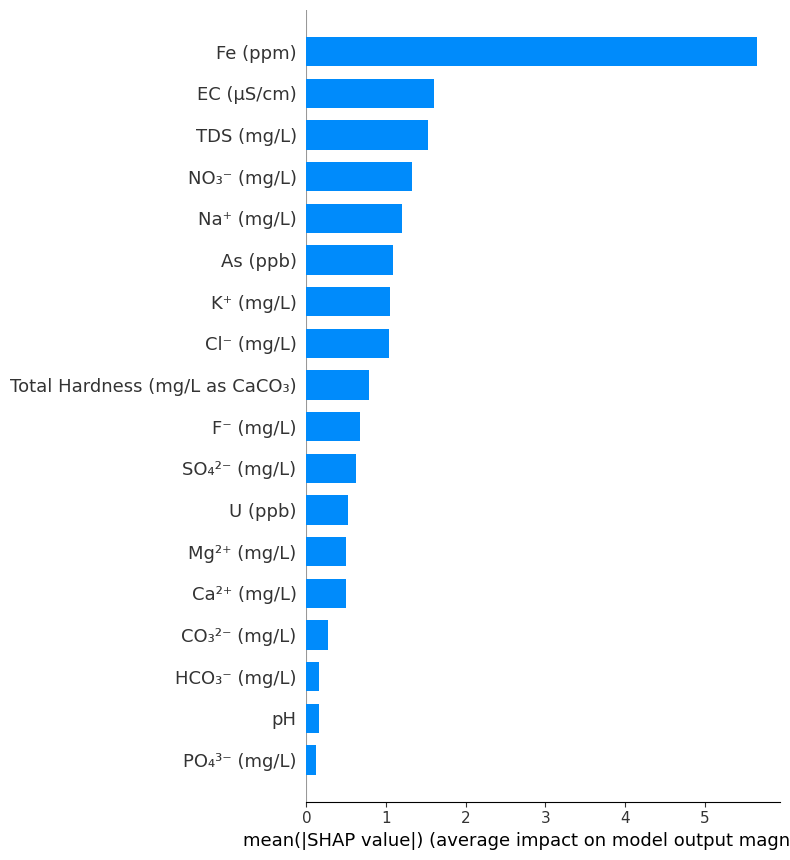

In [ ]:
#MLP (ANN) (Train on GRB excluding VRB, Test on VRB)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import explained_variance_score
import shap

# === Load GRB and VRB datasets ===
grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

# === Define features and target ===
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# === Clean data ===
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# === Prepare training and test sets ===
x_train = grb[features]
y_train = grb[target]
x_test = vrb[features]
y_test = vrb[target]

# === Impute (if necessary) ===
imputer = SimpleImputer(strategy="mean")
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=features)
x_test = pd.DataFrame(imputer.transform(x_test), columns=features)

# === Scale ===
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=features)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=features)

# === Define MLP Regressor ===
model_ann = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', alpha=0.001, learning_rate='adaptive',
                         max_iter=500, random_state=42)

# === Train & Test ===
model_ann.fit(x_train_scaled, y_train)
y_pred = model_ann.predict(x_test_scaled)

# === Evaluate ===
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MLP (Trained on GRB excl. VRB → Tested on VRB):")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")
print(f"MAPE: {mape:.2f}%")

# === SHAP Analysis (Optional, may be unstable for MLP) ===
try:
    explainer = shap.Explainer(model_ann.predict, x_train_scaled)
    shap_values = explainer(x_train_scaled)
    shap_array = shap_values.values if hasattr(shap_values, 'values') else shap_values
    shap_mean = np.abs(shap_array).mean(axis=0)
    shap_weights = pd.Series(shap_mean, index=features)
    shap_weights_normalized = shap_weights / shap_weights.sum()
    print("\nNormalized SHAP Feature Weights (for PPI):")
    print(shap_weights_normalized.sort_values(ascending=False))

    shap.summary_plot(shap_array, x_train_scaled, plot_type="bar", show=True)
except Exception as e:
    print("\nSHAP analysis failed due to:", e)


Training base model: rf
Training base model: et
Training base model: xgb
Training base model: cat
Training base model: mlp

Evaluation on VRB Test Set:
MAE: 0.89
MSE: 1.34
R² Score: 0.962

SHAP values

Normalized SHAP Feature Weights (for Pollution Pressure Index):
Fe (ppm)                          0.319538
TDS (mg/L)                        0.148454
EC (µS/cm)                        0.115208
NO₃⁻ (mg/L)                       0.066894
As (ppb)                          0.057851
K⁺ (mg/L)                         0.048948
Total Hardness (mg/L as CaCO₃)    0.047050
Cl⁻ (mg/L)                        0.045097
U (ppb)                           0.042574
SO₄²⁻ (mg/L)                      0.029554
PO₄³⁻ (mg/L)                      0.025879
F⁻ (mg/L)                         0.018147
Na⁺ (mg/L)                        0.014236
Mg²⁺ (mg/L)                       0.012679
HCO₃⁻ (mg/L)                      0.002675
CO₃²⁻ (mg/L)                      0.002143
Ca²⁺ (mg/L)                       0.002128
pH 

/tmp/ipython-input-6-1570746423.py:80: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


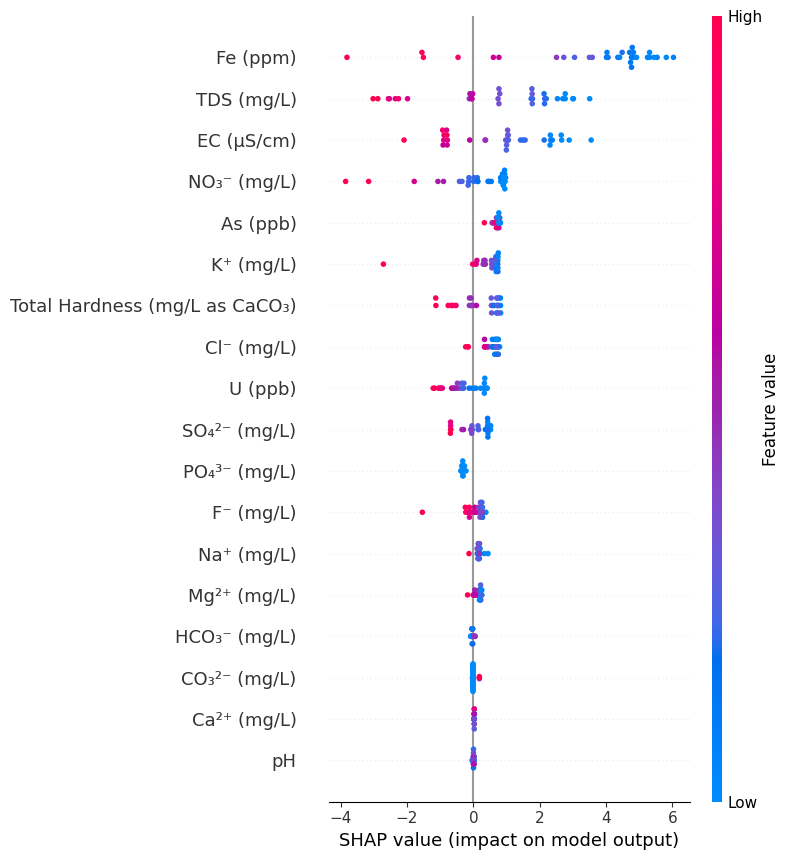


SHAP Bar Chart (Mean Absolute Importance):


/tmp/ipython-input-6-1570746423.py:83: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


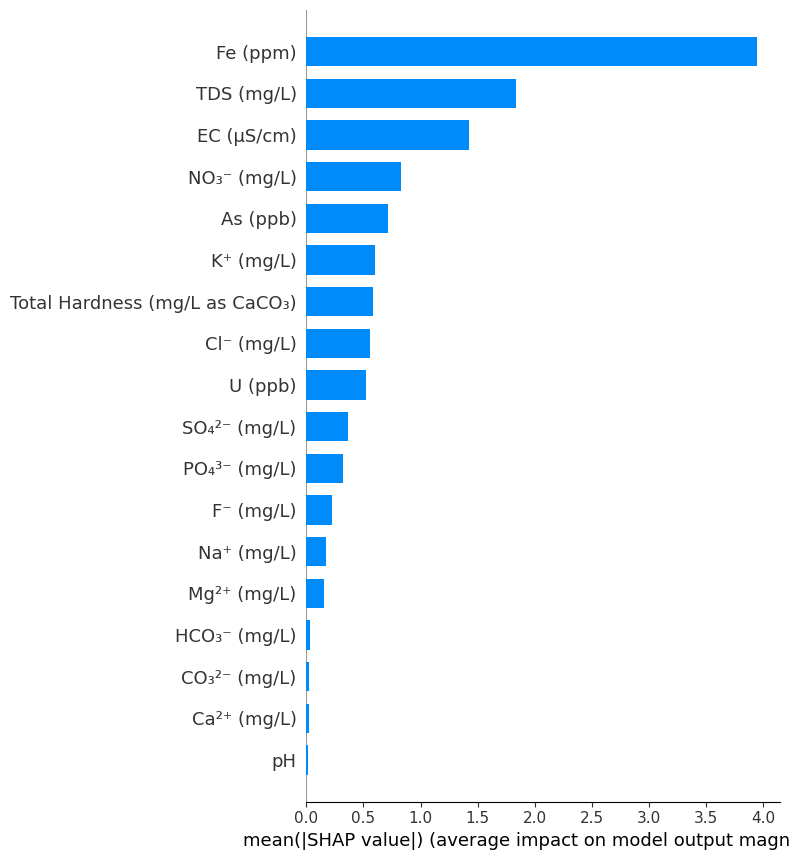


Beeswarm Plot


/tmp/ipython-input-6-1570746423.py:87: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)


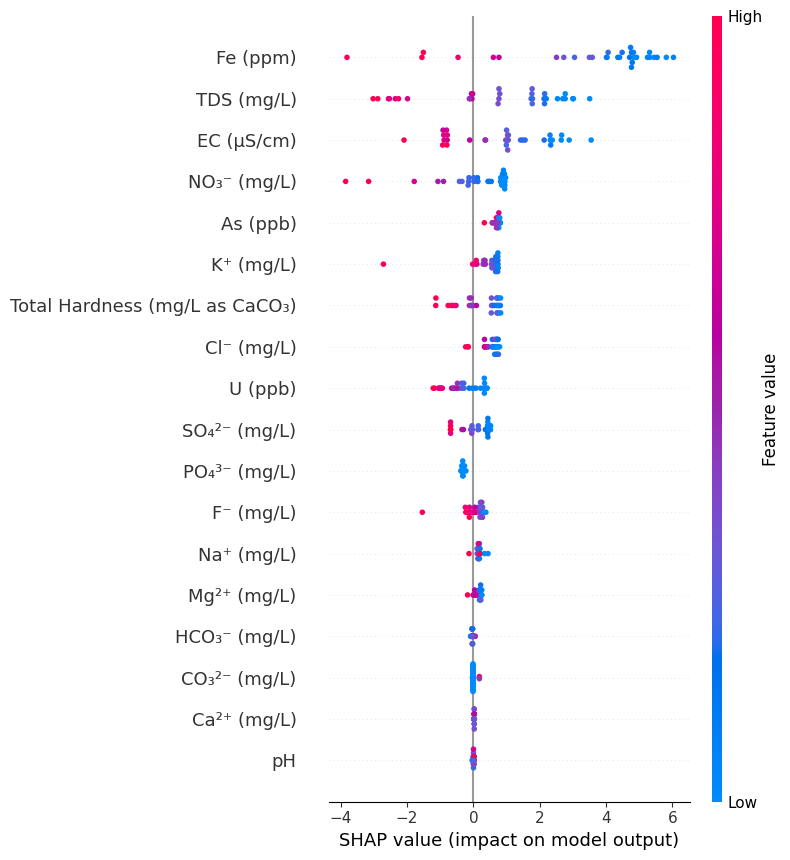

In [ ]:
#Stacked Ensemble (Train on GRB excluding VRB, Test on VRB)
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_predict
import shap


grb = pd.read_csv("GRB_excluding_VRB.csv")
vrb = pd.read_csv("Varuna_River_Basin_Clean_GWQI.csv")

# Feature and target columns
features = ["pH", "EC (µS/cm)", "CO₃²⁻ (mg/L)", "HCO₃⁻ (mg/L)", "Cl⁻ (mg/L)", "F⁻ (mg/L)",
            "SO₄²⁻ (mg/L)", "NO₃⁻ (mg/L)", "PO₄³⁻ (mg/L)", "Total Hardness (mg/L as CaCO₃)",
            "Ca²⁺ (mg/L)", "Mg²⁺ (mg/L)", "Na⁺ (mg/L)", "K⁺ (mg/L)", "Fe (ppm)", "As (ppb)",
            "U (ppb)", "TDS (mg/L)"]
target = "GWQI (0–100 Index)"

# Clean missing data
grb = grb.dropna(subset=features + [target])
vrb = vrb.dropna(subset=features + [target])

# Split features and target
X_train = grb[features]
y_train = grb[target]
X_test = vrb[features]
y_test = vrb[target]

# Define base models
base_models = [
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("et", ExtraTreesRegressor(n_estimators=100, random_state=42)),
    ("xgb", XGBRegressor(n_estimators=100, random_state=42, verbosity=0)),
    ("cat", CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0)),
    ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
]

# Generate meta-model inputs using cross-validated predictions
meta_X = np.zeros((X_train.shape[0], len(base_models)))
meta_X_test = np.zeros((X_test.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models):
    print(f"Training base model: {name}")
    meta_X[:, i] = cross_val_predict(model, X_train, y_train, cv=5, n_jobs=-1)
    model.fit(X_train, y_train)
    meta_X_test[:, i] = model.predict(X_test)

# Train meta-learner
meta_model = RidgeCV(alphas=np.logspace(-3, 3, 7))
meta_model.fit(meta_X, y_train)
ensemble_preds = meta_model.predict(meta_X_test)

# Evaluate on VRB
print("\nEvaluation on VRB Test Set:")
print("MAE:", round(mean_absolute_error(y_test, ensemble_preds), 2))
print("MSE:", round(mean_squared_error(y_test, ensemble_preds), 2))
print("R² Score:", round(r2_score(y_test, ensemble_preds), 3))

# SHAP analysis
print("\nSHAP values")
cat_model = base_models[3][1]  # CatBoost is the 4th model (already trained)
explainer = shap.Explainer(cat_model, X_train)
shap_values = explainer(X_test)

# Mean absolute value for each feature
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Normalize feature importance
shap_weights = pd.Series(shap_importance, index=features)
shap_weights_normalized = shap_weights / shap_weights.sum()
shap_weights_normalized = shap_weights_normalized.sort_values(ascending=False)

# Display SHAP weights
print("\nNormalized SHAP Feature Weights (for Pollution Pressure Index):")
print(shap_weights_normalized)

# SHAP Summary Plots
print("\nSHAP Summary Plot:")
shap.summary_plot(shap_values, X_test, show=True)

print("\nSHAP Bar Chart (Mean Absolute Importance):")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# SHAP Beeswarm Plot
print("\nBeeswarm Plot")
shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)

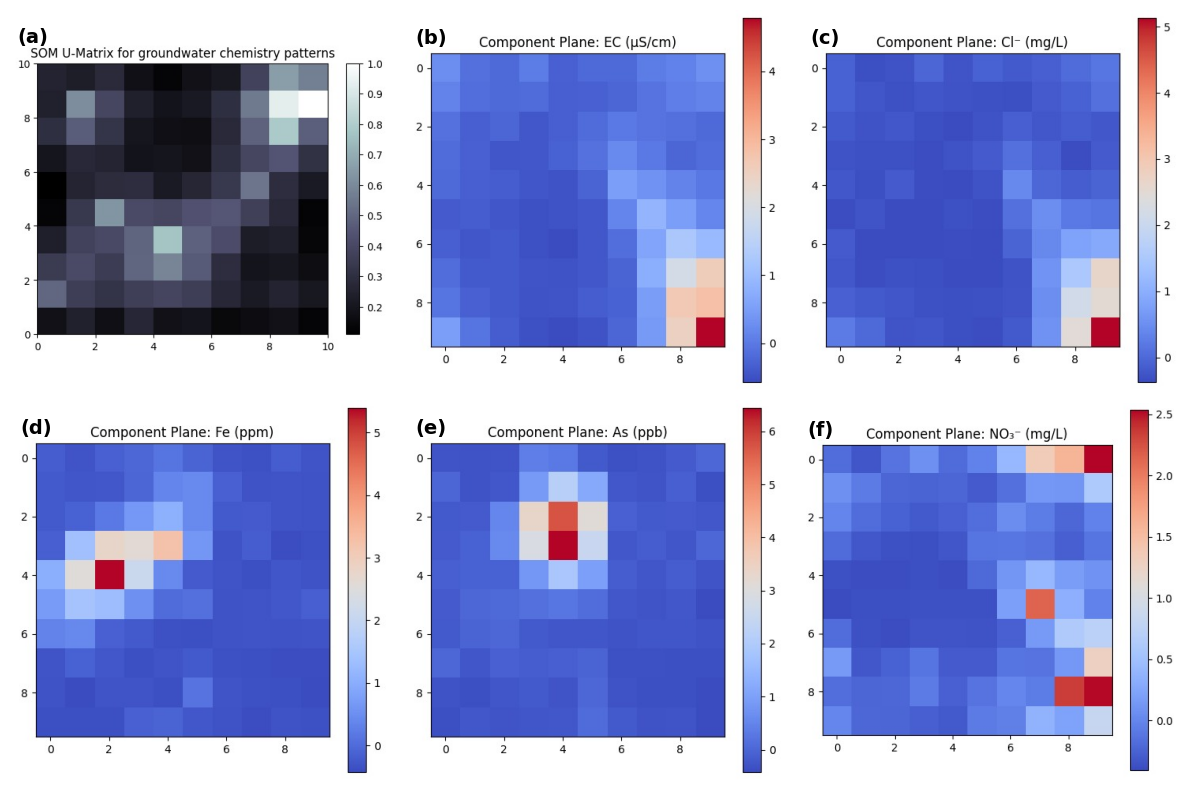

In [ ]:
#Multi-panel SOM GRB Figure
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
images = [
    "/content/SOM GRB U Matrix.png",
    "/content/SOM GRB EC.png",
    "/content/SOM GRB Cl.png",
    "/content/SOM GRB Fe.png",
    "/content/SOM GRB As.png",
    "/content/SOM GRB NO3.png"
]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')
    y_pos = 1.04 if i == 0 else 0.95   # raise only (a)
    ax.text(0.02, y_pos, labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            verticalalignment='top')
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.tight_layout()
plt.savefig("SOM Figures GRB.png", dpi=600, bbox_inches='tight')
plt.show()

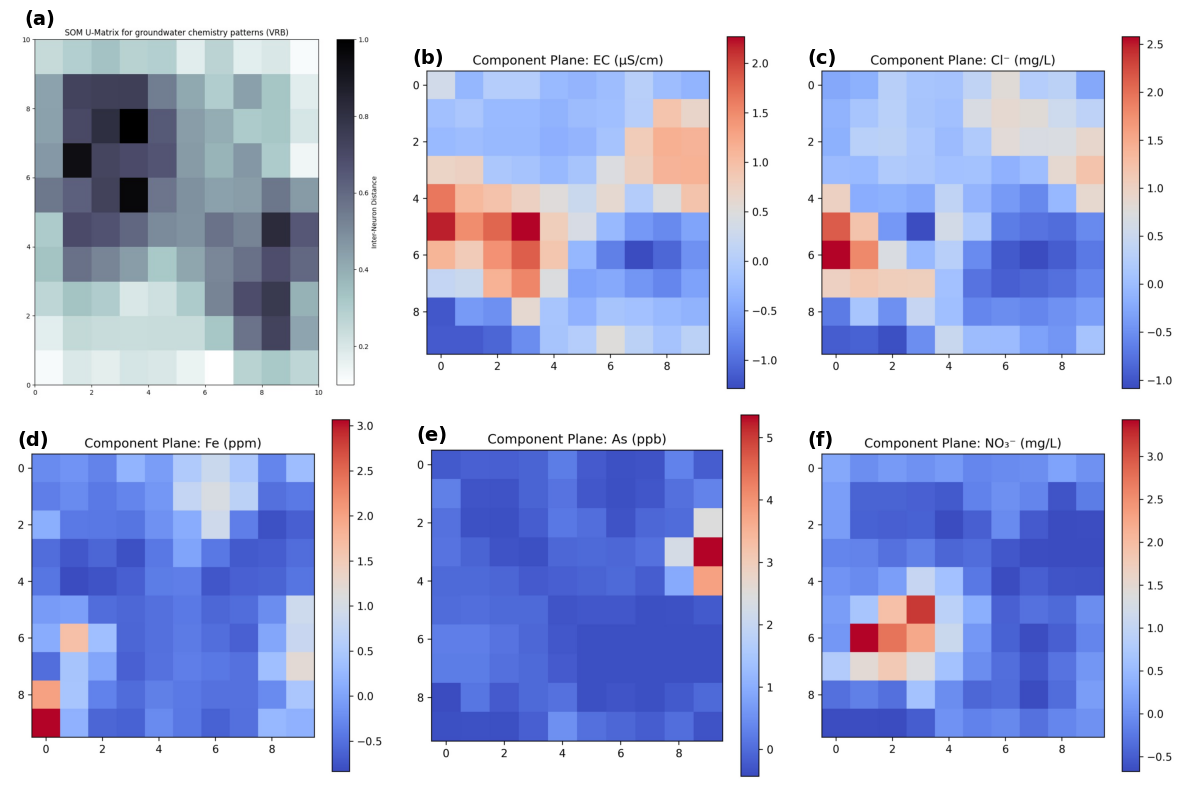

In [ ]:
#Multi-panel SOM VRB Figure
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
images = [
    "/content/SOM VRB U Matrix.png",
    "/content/SOM VRB EC.png",
    "/content/SOM VRB Cl.png",
    "/content/SOM VRB Fe.png",
    "/content/SOM VRB As.png",
    "/content/SOM VRB NO3.png"
]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')
    y_pos = 1.04 if i == 0 else 0.95   # raise only (a)
    ax.text(0.02, y_pos, labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            verticalalignment='top')
plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.tight_layout()
plt.savefig("SOM Figures VRB.png", dpi=600, bbox_inches='tight')
plt.show()

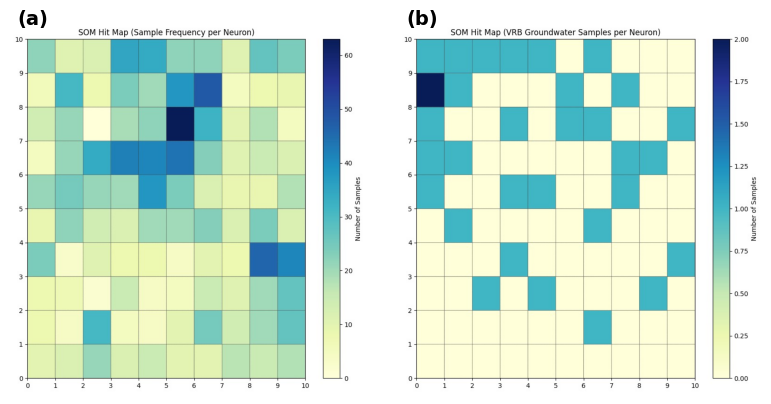

In [ ]:
#SOM Hit Map Multi-panel
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
images = [
    "/content/SOM Hit Map GRB.png",
    "/content/SOM Hit Map VRB.png"
]
labels = ['(a)', '(b)']
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, ax in enumerate(axes):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')
    y_pos = 1.04 if i in [0,1] else 0.95
    ax.text(0.02, y_pos, labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            verticalalignment='top')
plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
plt.savefig("SOM Hit Map.png", dpi=600, bbox_inches='tight')
plt.show()

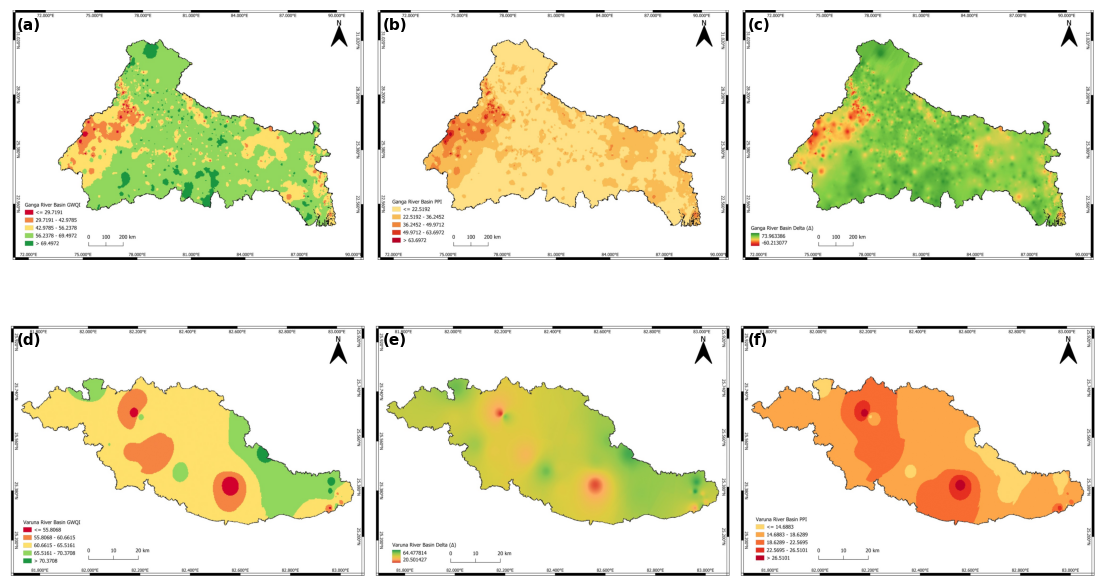

In [ ]:
#GRB VRB Maps Multi-Panel Figure
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
images = [
    "/content/GRB GWQI.png",
    "/content/GRB PPI.png",
    "/content/GRB Delta.png",
    "/content/VRB GWQI.png",
    "/content/VRB Delta.png",
    "/content/VRB PPI.png"
]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')
    ax.text(
        0.02, 0.97,
        labels[i],
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        va='top'
    )
plt.subplots_adjust(wspace=0.03, hspace=0.05)
plt.savefig("multi_panel_maps.png", dpi=600, bbox_inches='tight')
plt.show()